# 13 — HGT graphe-puits **évalué en validation croisée spatiale**

Ce notebook reprend le banc à cinq modèles du NB 12 (graphe-puits, split par puits) et
comble le trou méthodologique persistant depuis le NB 09 : **le HGT n'avait jamais été
évalué en validation croisée spatiale par blocs**. La section CV spatiale des NB 09→12 ne
testait que Random Forest et XGBoost sur features tabulaires — d'où des chiffres identiques
d'un run à l'autre et le pari central du mémoire (« la structure relationnelle généralise-t-elle
mieux hors-zone que la position mémorisée ? ») laissé sans réponse.

**Ce que le run principal du NB 12 a établi** (split par puits, évaluation aléatoire) :
- Ablation propre : NB 11 (graphe-échantillons) 0.8425 → graphe-puits **seul** 0.8770 (+3,5,
  dû au graphe) → graphe-puits **+ feature étiquetée** 0.9057 (+2,9, dû à la feature). Les deux
  contributions sont réelles et d'ampleur comparable ; le gain du graphe n'est pas un artefact.
- Connectivité : 59,8 % des arêtes puits↔puits d'un puits test pointent vers le train (17,3 % au NB 11).
- **Mais** en interpolation (split par puits, voisin connu toujours proche) tout le monde plafonne
  vers 0.90–0.91, porté à ~0.87 par la seule autocorrélation spatiale.

**Run FINAL** — intègre toutes les pistes des analyses précédentes :
1. **Graphe refactoré en fonction** `assemble_well_graph(...)` — arêtes (kNN par bandes, sources,
   sous-bassins, advection) précalculées une fois ; seuls les features `well` et les masques
   changent → un graphe transductif propre par bloc spatial.
2. **CV spatiale par blocs incluant le HGT** (`SPATIAL_CV_HGT=True`) : par fold, refit préproc/scaler
   sur le train, reconstruction du graphe, réentraînement du HGT (early stopping), éval sur le bloc
   test. RF, XGBoost, Embedding Fusion en parallèle. Feature étiquetée **exclue** de la CV (dégrade
   hors-zone) → structure pure.
3. **Arêtes advectives amont→aval** (`USE_FLOW_EDGES`, relation `flows_to`) du gradient hydraulique
   DWR (`flow_dir_sin/cos`) — seule info physique que ni le kNN symétrique ni les features n'encodent.
4. **Bras « features mécanistes transférables »** en CV spatiale (`SPATIAL_CV_TRANSFER`) — plancher
   honnête d'extrapolation (dev_intensity, profondeur nappe/crépine, élévation…).
5. **Section interprétation** (`RUN_INTERPRET`, figures NB 09/10) : SHAP arbres, importance HGT par
   groupe, concordance des rangs RF/XGB/HGT, embeddings 2D, ego-graph d'un puits contaminé, et
   **apport quantifié du message-passing** (Δ AUC avec vs sans voisinage).

Le reste (cibles EPA 2024, graphe-puits, bandes de distance, HPO sur AUC val, résidus+LayerNorm+
jumping knowledge, stacking honnête, early stopping, GPU, hub geo_cluster) est repris du NB 12.

In [1]:
# --- Detection de l'environnement ---
import sys, importlib.util, subprocess
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

if IN_COLAB:
    print("Google Colab detecte — installation des dependances...")
    import torch
    tv = torch.__version__.split("+")[0]
    cu = ("cu" + torch.version.cuda.replace(".", "")) if torch.version.cuda else "cpu"
    print(f"  torch={tv} | backend={cu}")
    _pip("torch_geometric")
    _pip("pyg_lib", "torch_scatter", "torch_sparse",
         "-f", f"https://data.pyg.org/whl/torch-{tv}+{cu}.html")
    _pip("xgboost", "optuna", "shap", "seaborn", "pyarrow", "networkx")
    print("Installation terminee.")
else:
    print("Environnement local — verification des librairies (aucune installation).")
    for m in ["torch", "torch_geometric", "xgboost", "optuna", "shap"]:
        ok = importlib.util.find_spec(m) is not None
        print(f"  {m:16s}: {'OK' if ok else 'MANQUANT'}")

Google Colab detecte — installation des dependances...
  torch=2.11.0 | backend=cu128
Installation terminee.


In [2]:
import warnings, json, pickle, time, os, zipfile
from pathlib import Path
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, StratifiedKFold,
    GroupShuffleSplit, cross_val_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve, accuracy_score,
    recall_score, precision_score, balanced_accuracy_score)
from sklearn.neighbors import NearestNeighbors, BallTree

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# GPU reactive (le NB11 a tourne sur CPU). Repassez FORCE_CPU=True si le GPU
# Colab plante (CUDA device-side assert), puis Redemarrer la session.
FORCE_CPU = False
if FORCE_CPU:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import HGTConv, Linear as PyGLinear
    TORCH_GEOMETRIC_AVAILABLE = True
except Exception as e:
    TORCH_GEOMETRIC_AVAILABLE = False
    print("PyTorch Geometric indisponible :", e)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
print("Imports OK | PyG disponible :", TORCH_GEOMETRIC_AVAILABLE)

Imports OK | PyG disponible : True


In [3]:
# ════════════════════════════════════════════════════════════════════════
#  CONFIGURATION GLOBALE
# ════════════════════════════════════════════════════════════════════════
RANDOM_STATE = 42

# --- Donnees ---
DATA_FILENAME      = "CA-PFAS-ASGWS_v2.parquet"
MISSING_THRESHOLD  = 0.40
DROP_LOCATION      = False
DEV_SUBSAMPLE      = None    # int (ex 5000) pour un test rapide

# --- Split ---
TEST_SIZE = 0.20
VAL_SIZE  = 0.25             # part du reste -> 60/20/20
GROUP_SPLIT_BY_WELL = True   # aucun puits (gm_well_id) a cheval train/test

# --- Graphe PUITS (transductif) ---
WELL_KNN_K       = 10                  # k plus proches PUITS (uniques) par puits
WELL_BANDS_KM    = (2.0, 10.0, 30.0)   # bandes de distance -> relations distinctes
REGION_COL       = "sgma_subbasin_name"
USE_GEO_CLUSTER  = True                # hub KMeans (repris des runs (1)/(2))
N_GEO_CLUSTERS   = 20
USE_SOURCE_NODES = True
SITES_FILENAME   = "geotracker_pfas_investigation_sites.csv"
SOURCE_BANDS_KM  = (10.0, 50.0)        # bandes puits->site (site le + proche tjrs garde)
SOURCE_KMAX      = 6

# --- Arêtes advectives orientées amont->aval (piste "flows_to") ---
# Relation asymétrique puits->puits alignée sur la direction d'écoulement (gradient DWR).
# La seule information physique que ni le kNN symétrique ni les features n'encodent.
USE_FLOW_EDGES   = True
FLOW_COS_THRESH  = 0.5                  # |proj| mini (cos ~60°) pour retenir une arête orientée
FLOW_MIN_GRAD    = 0.0                  # gradient hydraulique mini (permil) ; 0 = pas de filtre

# --- Features spatiales etiquetees (fournies a TOUS les modeles) ---
ADD_SPATIAL_LABEL_FEATURES = True      # moyenne ponderee des labels des puits TRAIN voisins
K_LABEL_NEIGHBORS          = 10        # (leave-one-well-out, aucune fuite val/test)

# --- Interprétation / figures pour le rapport final (reprises NB09/NB10) ---
RUN_INTERPRET    = True                # SHAP arbres, importance HGT, embeddings 2D, ego-graph, ablation message-passing
SHAP_SAMPLE      = 1500                # échantillons test pour SHAP arbres
# Features mécanistes transférables (bras "plancher honnête" de la CV spatiale, cf audits intra-bloc)
TRANSFER_FEATURES = ["dev_intensity", "depth_to_water_m", "depth_to_water_log1p", "depth_eff_ft",
                     "depth_eff_log1p", "elevation_m", "lc_developed", "hydr_grad_mag_permil",
                     "dist_geotracker_km", "screen_mid_ft"]
SPATIAL_CV_TRANSFER = True             # bras XGB features transférables seules (plancher extrapolation)

# --- Optuna ---
OPTUNA_MODE = "FULL"
_TRIALS = {
    "FAST": {"rf": 8,  "xgb": 10, "hgt": 6,  "fusion": 8},
    "FULL": {"rf": 40, "xgb": 60, "hgt": 25, "fusion": 20},
}[OPTUNA_MODE]
OPTUNA_TIMEOUT = {"FAST": 300, "FULL": 1800}[OPTUNA_MODE]

# --- HGT ---
EPOCHS_HGT  = {"FAST": 60, "FULL": 300}[OPTUNA_MODE]
ES_PATIENCE = 50            # early stopping (epochs sans amelioration d'AUC val)

# --- Section finale : evaluation honnete (CV spatiale par blocs) ---
RUN_SPATIAL_CV     = True   # CV spatiale par blocs k=8 (long). Coeur de ce notebook.
SPATIAL_CV_K       = 8
SPATIAL_CV_HGT     = True   # inclure le HGT (reconstruit + reentraine par fold) : la piece manquante
SPATIAL_CV_FUSION  = True   # inclure Embedding Fusion (embeddings HGT du fold + XGB)
SPATIAL_CV_HGT_EPOCHS   = {"FAST": 40, "FULL": 200}[OPTUNA_MODE]  # epochs HGT par fold (pas d'Optuna)
SPATIAL_CV_HGT_PATIENCE = 30    # early stopping par fold
SPATIAL_CV_INNER_VAL    = 0.15  # part du train-fold reservee en val interne (par puits)

# --- Reglementation EPA 2024 NPDWR ---
EPA2024_MCLS = {"PFOA_ngL": 4.0, "PFOS_ngL": 4.0, "PFNA_ngL": 10.0,
                "PFHxS_ngL": 10.0, "HFPO_DA_ngL": 10.0}
HI_REFS = {"PFNA_ngL": 10.0, "PFHxS_ngL": 10.0, "HFPO_DA_ngL": 10.0, "PFBS_ngL": 2000.0}

np.random.seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    torch.manual_seed(RANDOM_STATE)
except Exception as _e:
    print("Avertissement CUDA :", _e); device = torch.device("cpu")

OUT_DIR    = Path("outputs_notebook_cv_spatiale")
FIG_DIR    = OUT_DIR / "figures"
RES_DIR    = OUT_DIR / "results"
MODELS_DIR = OUT_DIR / "models"
for d in (FIG_DIR, RES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

EARTH_KM = 6371.0
print(f"Mode Optuna : {OPTUNA_MODE} | trials={_TRIALS} | epochs HGT={EPOCHS_HGT} (patience {ES_PATIENCE})")
print(f"Split par puits : {GROUP_SPLIT_BY_WELL} | Device : {device}")

Mode Optuna : FULL | trials={'rf': 40, 'xgb': 60, 'hgt': 25, 'fusion': 20} | epochs HGT=300 (patience 50)
Split par puits : True | Device : cuda


In [4]:
GITHUB_REPO_RAW = ("https://raw.githubusercontent.com/dnwiloic/pfas-gnn/"
                   "d31351fa9e83b7dda9ea252bdecd51c374d9b8e9/data")

def locate_dataset(filename):
    candidates = [Path(filename), Path("data/processed")/filename,
                  Path("../data/processed")/filename,
                  Path("data/raw/contamination")/filename,
                  Path("../data/raw/contamination")/filename,
                  Path("/content")/filename, Path("/content/drive/MyDrive")/filename]
    for c in candidates:
        if c.exists():
            return c
    # Telechargement automatique depuis GitHub (repo public dnwiloic/pfas-gnn)
    try:
        import urllib.request
        url = f"{GITHUB_REPO_RAW}/{filename}"
        dest = Path(filename)
        print(f"Fichier local introuvable -> telechargement depuis GitHub : {url}")
        urllib.request.urlretrieve(url, dest)
        if dest.exists() and dest.stat().st_size > 0:
            print(f"  OK -> {dest} ({dest.stat().st_size/1e6:.1f} Mo)")
            return dest
    except Exception as e:
        print(f"  Echec du telechargement GitHub : {e}")
    if IN_COLAB:
        from google.colab import files
        print(f"Veuillez televerser '{filename}' :")
        up = files.upload()
        return Path(list(up.keys())[0])
    raise FileNotFoundError(f"{filename} introuvable — placez-le a cote du notebook.")

DATA_PATH = locate_dataset(DATA_FILENAME)
df = pd.read_parquet(DATA_PATH)
if DEV_SUBSAMPLE:
    df = df.sample(n=min(DEV_SUBSAMPLE, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"[DEV] sous-echantillon : {len(df)} lignes")
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes  (source: {DATA_PATH})")

Fichier local introuvable -> telechargement depuis GitHub : https://raw.githubusercontent.com/dnwiloic/pfas-gnn/d31351fa9e83b7dda9ea252bdecd51c374d9b8e9/data/CA-PFAS-ASGWS_v2.parquet
  OK -> CA-PFAS-ASGWS_v2.parquet (4.4 Mo)
Dataset : 46,338 lignes x 217 colonnes  (source: CA-PFAS-ASGWS_v2.parquet)


In [5]:
sites_df = None
if USE_SOURCE_NODES:
    try:
        sp = locate_dataset(SITES_FILENAME)
        sites_df = pd.read_csv(sp).dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
        print(f"Sites GeoTracker charges : {len(sites_df)}  (source: {sp})")
    except Exception as e:
        USE_SOURCE_NODES = False
        print(f"Sites GeoTracker indisponibles -> noeuds 'source' desactives ({e})")
else:
    print("Noeuds 'source' desactives (USE_SOURCE_NODES=False)")

Fichier local introuvable -> telechargement depuis GitHub : https://raw.githubusercontent.com/dnwiloic/pfas-gnn/d31351fa9e83b7dda9ea252bdecd51c374d9b8e9/data/geotracker_pfas_investigation_sites.csv
  OK -> geotracker_pfas_investigation_sites.csv (0.1 Mo)
Sites GeoTracker charges : 463  (source: geotracker_pfas_investigation_sites.csv)


In [6]:
def compute_target_epa2024(d):
    exceeded = pd.Series(False, index=d.index)
    for col, mcl in EPA2024_MCLS.items():
        if col in d.columns:
            exceeded |= d[col].fillna(0) > mcl
    hi = sum(d[c].fillna(0) / r for c, r in HI_REFS.items() if c in d.columns)
    exceeded |= hi > 1.0
    return exceeded.astype(int)

df["target"] = compute_target_epa2024(df)
n_pos = int(df["target"].sum()); n_neg = len(df) - n_pos
print(f"Positifs (>= MCL ou HI>1) : {n_pos:,}  ({100*n_pos/len(df):.2f}%)")
print(f"Negatifs (< MCL)          : {n_neg:,}  ({100*n_neg/len(df):.2f}%)")

Positifs (>= MCL ou HI>1) : 21,154  (45.65%)
Negatifs (< MCL)          : 25,184  (54.35%)


In [7]:
# ── Sources de fuite (identiques NB09/10/11) ────────────────────────────
LEAK_SUFFIXES      = ("_ngL",)
LEAK_BOOL_SUFFIXES = ("_detected",)
LEAK_PREFIXES      = ("label_",)
LEAK_EXACT = {
    "sum_pfas_ngL", "pfas_class_assignment", "gm_well_id", "collection_date",
    "target", "target_sum_gt70", "gm_dataset_name", "gldas_dist_km",
}
DROP_REDUNDANT = {"dwr_basin", "sgma_basin_name", "sgma_subbasin_name"}

if "collection_date" in df.columns:
    _dt = pd.to_datetime(df["collection_date"], errors="coerce")
    df["year"]   = _dt.dt.year
    df["month"]  = _dt.dt.month
    df["season"] = ((_dt.dt.month % 12) // 3 + 1).astype("float")

_miss = df.isna().mean()
HIGH_MISSING_DROP = set(_miss[_miss > MISSING_THRESHOLD].index)

LOCATION_FEATURES = {"latitude", "longitude", "county", "regional_board",
                     "dwr_region", "sgma_region_office"}
loc_drop = LOCATION_FEATURES if DROP_LOCATION else set()

CATEGORICAL_CANDIDATES = ["county", "regional_board", "dwr_region", "gm_well_category",
                          "sgma_region_office", "nearest_geotracker_type", "soil_texture_class"]
cat_cols = [c for c in CATEGORICAL_CANDIDATES
            if c in df.columns and c not in loc_drop and c not in HIGH_MISSING_DROP]

def _is_leak(c):
    return (any(c.endswith(s) for s in LEAK_SUFFIXES)
            or any(c.endswith(s) for s in LEAK_BOOL_SUFFIXES)
            or any(c.startswith(p) for p in LEAK_PREFIXES)
            or c in LEAK_EXACT)

num_cols = [c for c in df.columns
            if df[c].dtype.kind in ("f", "i", "u")
            and not _is_leak(c) and c not in HIGH_MISSING_DROP
            and c not in DROP_REDUNDANT and c not in loc_drop and c not in cat_cols]

feature_names = num_cols + cat_cols
print(f"Features numeriques : {len(num_cols)} | categorielles : {len(cat_cols)} | TOTAL : {len(feature_names)}")
assert not any(_is_leak(c) for c in feature_names), "FUITE detectee dans les features !"
print("Verification anti-fuite : OK")

Features numeriques : 96 | categorielles : 7 | TOTAL : 103
Verification anti-fuite : OK


## Split, structures puits

Chaque échantillon est rattaché à son puits (`winv`). Les coordonnées, effectifs et
appartenance train/val/test sont calculés **au niveau puits** — c'est la maille du graphe.

In [8]:
X = df[feature_names].copy()
y = df["target"].values
idx_all = np.arange(len(df))

# ── Structures puits ─────────────────────────────────────────────────────
wid_all = np.asarray(df["gm_well_id"].astype(str)) if "gm_well_id" in df.columns \
          else np.asarray([f"w{i}" for i in idx_all])
wcats, winv = np.unique(wid_all, return_inverse=True)
n_wells = len(wcats)
wcnt = np.bincount(winv).astype(float)
well_coords = np.zeros((n_wells, 2))
np.add.at(well_coords[:, 0], winv, df["latitude"].values)
np.add.at(well_coords[:, 1], winv, df["longitude"].values)
well_coords /= wcnt[:, None]
print(f"{len(df):,} echantillons -> {n_wells:,} puits ({len(df)/n_wells:.2f} ech/puits)")

# ── Split ────────────────────────────────────────────────────────────────
if GROUP_SPLIT_BY_WELL:
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    idx_tmp, idx_test = next(gss.split(idx_all, y, groups=wid_all))
    gss2 = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=RANDOM_STATE)
    a, b = next(gss2.split(idx_tmp, y[idx_tmp], groups=wid_all[idx_tmp]))
    idx_train, idx_val = idx_tmp[a], idx_tmp[b]
    assert not (set(wid_all[idx_train]) & set(wid_all[idx_test])), "puits a cheval train/test !"
    print(f"Split PAR PUITS — puits uniques : train {len(np.unique(winv[idx_train])):,} | "
          f"val {len(np.unique(winv[idx_val])):,} | test {len(np.unique(winv[idx_test])):,}")
else:
    idx_tmp, idx_test = train_test_split(idx_all, test_size=TEST_SIZE,
                                         stratify=y, random_state=RANDOM_STATE)
    idx_train, idx_val = train_test_split(idx_tmp, test_size=VAL_SIZE,
                                          stratify=y[idx_tmp], random_state=RANDOM_STATE)
    print("Split aleatoire stratifie")

y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]
print(f"Train: {len(idx_train):,} ({100*y_train.mean():.1f}% +) | "
      f"Val: {len(idx_val):,} ({100*y_val.mean():.1f}% +) | "
      f"Test: {len(idx_test):,} ({100*y_test.mean():.1f}% +)")

# statut de chaque puits (train prioritaire si split aleatoire melange un puits)
well_split = np.full(n_wells, 2)                    # 2=test par defaut
well_split[np.unique(winv[idx_val])] = 1
well_split[np.unique(winv[idx_train])] = 0
print("Puits par statut (0=train,1=val,2=test) :", np.bincount(well_split, minlength=3))

46,338 echantillons -> 11,333 puits (4.09 ech/puits)
Split PAR PUITS — puits uniques : train 6,799 | val 2,267 | test 2,267
Train: 27,894 (46.5% +) | Val: 9,264 (45.0% +) | Test: 9,180 (43.8% +)
Puits par statut (0=train,1=val,2=test) : [6799 2267 2267]


## Features spatiales étiquetées (leave-one-well-out, train uniquement)

Pour chaque puits : moyenne pondérée par l'inverse de la distance des taux de contamination
des `K_LABEL_NEIGHBORS` puits **d'entraînement** les plus proches (son propre puits exclu),
plus la distance au puits train le plus proche. Aucun label val/test n'entre dans le calcul.
Ces deux features sont données à **tous** les modèles (tabulaires et HGT) — la comparaison
reste équitable. L'AUC de la feature seule, imprimée ci-dessous, sert de baseline « spatial pur ».

In [9]:
if ADD_SPATIAL_LABEL_FEATURES:
    tr_wells = np.unique(winv[idx_train])
    lab_sum = np.zeros(n_wells); lab_cnt = np.zeros(n_wells)
    np.add.at(lab_sum, winv[idx_train], y[idx_train])
    np.add.at(lab_cnt, winv[idx_train], 1)
    tw_label = lab_sum[tr_wells] / lab_cnt[tr_wells]      # taux de contamination du puits train

    ttree = BallTree(np.radians(well_coords[tr_wells]), metric="haversine")
    K2 = min(K_LABEL_NEIGHBORS + 1, len(tr_wells))
    d_, j_ = ttree.query(np.radians(well_coords), k=K2)
    d_km = d_ * EARTH_KM
    own = tr_wells[j_] == np.arange(n_wells)[:, None]     # exclut son propre puits (LOO)
    w_ = 1.0 / (d_km + 0.5); w_[own] = 0.0
    nbr_label = (w_ * tw_label[j_]).sum(1) / (w_.sum(1) + 1e-9)
    d_masked = np.where(own, np.inf, d_km)
    dist_train = np.log1p(d_masked.min(1))

    spatial_label_feats = np.column_stack([nbr_label[winv], dist_train[winv]]).astype("float32")
    SPATIAL_LABEL_NAMES = ["nbr_train_label_wmean", "log_dist_nearest_train_well_km"]
    auc_solo = roc_auc_score(y_test, spatial_label_feats[idx_test, 0])
    print(f"Baseline 'spatial pur' — AUC test de nbr_train_label_wmean seule : {auc_solo:.4f}")
else:
    spatial_label_feats = None; SPATIAL_LABEL_NAMES = []
    print("Features spatiales etiquetees desactivees")

Baseline 'spatial pur' — AUC test de nbr_train_label_wmean seule : 0.8722


In [10]:
# ── Preprocesseur (fit sur train, transform sur TOUT le dataset) ────────
numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",
                               unknown_value=-1, encoded_missing_value=-1)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
], remainder="drop")

preprocessor.fit(X.iloc[idx_train])
X_all_proc = preprocessor.transform(X)
proc_cols = num_cols + cat_cols
if spatial_label_feats is not None:
    X_all_proc = np.concatenate([X_all_proc, spatial_label_feats], axis=1)
    proc_cols = proc_cols + SPATIAL_LABEL_NAMES

scaler = StandardScaler().fit(X_all_proc[idx_train])
X_all_sc = scaler.transform(X_all_proc)
X_train_proc, X_val_proc, X_test_proc = (X_all_proc[i] for i in (idx_train, idx_val, idx_test))
print(f"X_all_proc {X_all_proc.shape} ({len(proc_cols)} features, "
      f"dont {len(SPATIAL_LABEL_NAMES)} spatiales etiquetees)")

X_all_proc (46338, 105) (105 features, dont 2 spatiales etiquetees)


In [11]:
RESULTS = {}

def evaluate(name, y_true, y_pred, y_proba, store=True, show=True):
    m = {"name": name,
         "roc_auc": roc_auc_score(y_true, y_proba),
         "avg_precision": average_precision_score(y_true, y_proba),
         "accuracy": accuracy_score(y_true, y_pred),
         "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
         "precision": precision_score(y_true, y_pred, zero_division=0),
         "recall": recall_score(y_true, y_pred),
         "f1": f1_score(y_true, y_pred)}
    if show:
        print(f"{'─'*52}\n  {name}\n{'─'*52}")
        for k in ["roc_auc","avg_precision","recall","precision","f1","balanced_accuracy","accuracy"]:
            print(f"  {k:20s}: {m[k]:.4f}")
    if store:
        RESULTS[name] = {"metrics": m, "y_pred": np.asarray(y_pred), "y_proba": np.asarray(y_proba)}
    return m

def plot_confusion(name, y_true, y_pred, fname):
    fig, ax = plt.subplots(figsize=(4.3, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=["< MCL (0)", ">= MCL (1)"],
        cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"Matrice de confusion — {name}")
    plt.tight_layout(); savefig(fig, fname); plt.show()

def optuna_history_fig(study, title, fname, color="steelblue"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    vals = [t.value for t in study.trials if t.value is not None]
    best = [max(vals[:i+1]) for i in range(len(vals))]
    axes[0].plot(vals, "o", alpha=.4, color=color, ms=5, label="Trial")
    axes[0].plot(best, "-", color="black", lw=2, label="Meilleur cumule")
    axes[0].set(xlabel="Trial", ylabel="Score objectif (AUC val)", title=f"{title} — historique Optuna")
    axes[0].legend(); axes[0].grid(alpha=.3)
    try:
        imp = optuna.importance.get_param_importances(study)
        axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color=color)
        axes[1].set(xlabel="Importance relative", title="Importance des hyperparametres")
    except Exception:
        axes[1].text(.5, .5, "Pas assez de trials", ha="center", transform=axes[1].transAxes)
    plt.tight_layout(); savefig(fig, fname); plt.show()

scale_pos = (y_train == 0).sum() / max(1, (y_train == 1).sum())
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Utilitaires prets. scale_pos_weight =", round(scale_pos, 3))

Utilitaires prets. scale_pos_weight = 1.152


## Modèle 1 — Random Forest (référence tabulaire)

  0%|          | 0/40 [00:00<?, ?it/s]

Meilleur AUC-CV : 0.9825 | params : {'n_estimators': 400, 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 2}


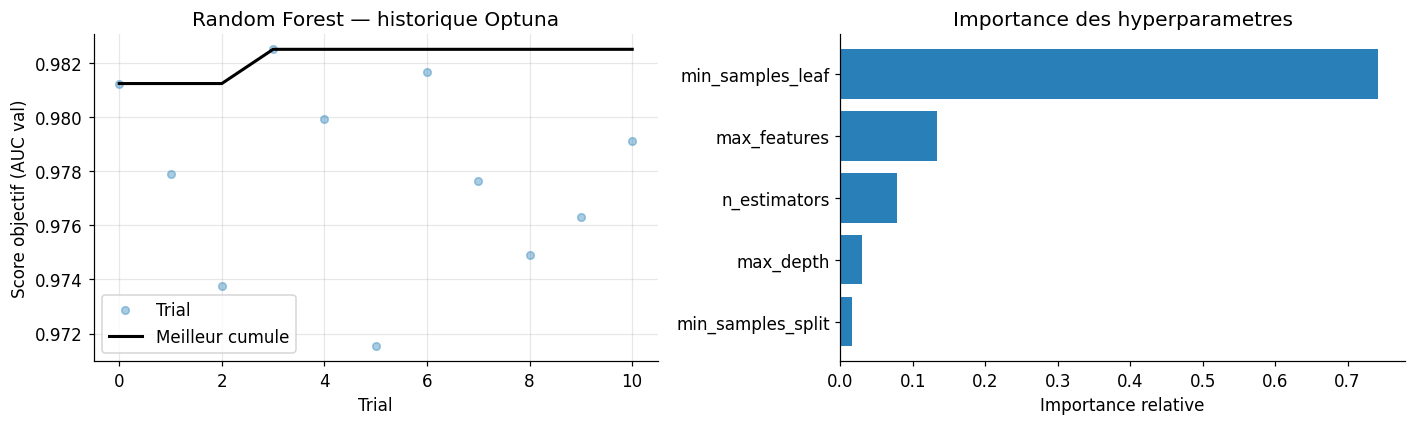

────────────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────────────
  roc_auc             : 0.8985
  avg_precision       : 0.8813
  recall              : 0.7248
  precision           : 0.8302
  f1                  : 0.7739
  balanced_accuracy   : 0.8046
  accuracy            : 0.8145


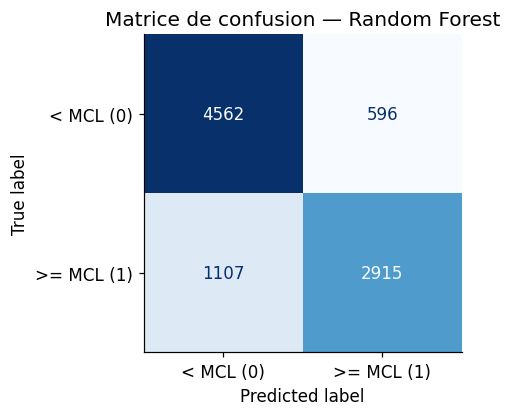

In [12]:
def objective_rf(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 800, step=100),
        max_depth=trial.suggest_categorical("max_depth", [None, 15, 20, 30]),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 15),
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
    sc = cross_val_score(RandomForestClassifier(**params), X_train_proc, y_train,
                         cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                         scoring="roc_auc", n_jobs=1)
    return sc.mean()

study_rf = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.enqueue_trial({"n_estimators": 500, "max_depth": None, "max_features": "sqrt",
                        "min_samples_leaf": 2, "min_samples_split": 2})
study_rf.optimize(objective_rf, n_trials=_TRIALS["rf"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
print("Meilleur AUC-CV :", round(study_rf.best_value, 4), "| params :", study_rf.best_params)
optuna_history_fig(study_rf, "Random Forest", "fig01_optuna_rf.png", color="#2980b9")

best_rf_params = {**study_rf.best_params, "class_weight": "balanced",
                  "n_jobs": -1, "random_state": RANDOM_STATE}
rf = RandomForestClassifier(**best_rf_params).fit(X_train_proc, y_train)
y_pred_rf  = rf.predict(X_test_proc)
y_proba_rf = rf.predict_proba(X_test_proc)[:, 1]
m_rf = evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf)
plot_confusion("Random Forest", y_test, y_pred_rf, "fig02_rf_confusion.png")

## Modèle 2 — XGBoost (référence tabulaire)

  0%|          | 0/60 [00:00<?, ?it/s]

Meilleur AUC-val : 0.8788 | params : {'n_estimators': 700, 'learning_rate': 0.028354808768228344, 'max_depth': 10, 'subsample': 0.918036407388451, 'colsample_bytree': 0.4042130256505134, 'min_child_weight': 6, 'gamma': 1.0147759762251243, 'reg_alpha': 3.154443500139822e-05, 'reg_lambda': 2.3132423684415434e-05}


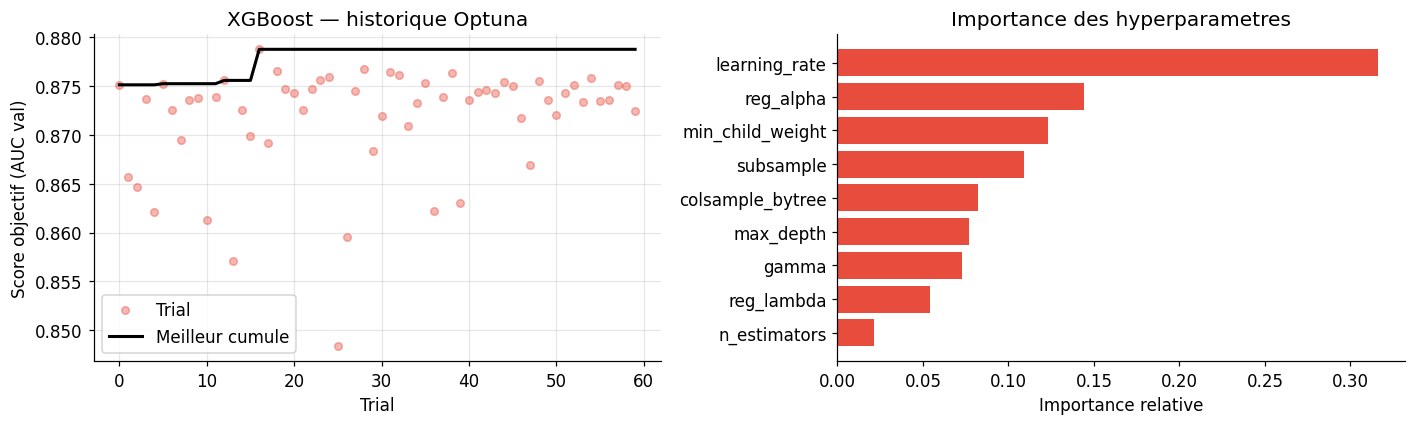

Best iteration : 322
────────────────────────────────────────────────────
  XGBoost
────────────────────────────────────────────────────
  roc_auc             : 0.9116
  avg_precision       : 0.8961
  recall              : 0.7499
  precision           : 0.8389
  f1                  : 0.7919
  balanced_accuracy   : 0.8188
  accuracy            : 0.8273


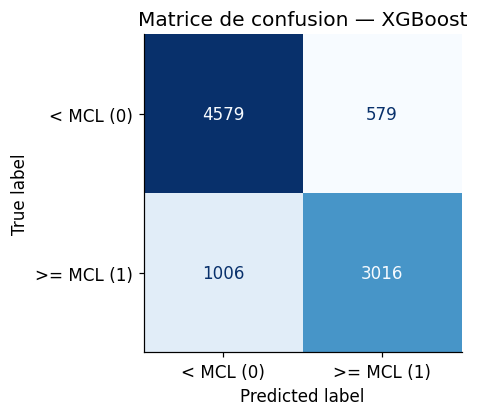

In [13]:
def objective_xgb(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 2000, step=100),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 15),
        gamma=trial.suggest_float("gamma", 0.0, 2.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        scale_pos_weight=scale_pos, tree_method="hist", n_jobs=-1,
        random_state=RANDOM_STATE, eval_metric="auc", verbosity=0)
    model = xgb.XGBClassifier(**params, early_stopping_rounds=40)
    model.fit(X_train_proc, y_train, eval_set=[(X_val_proc, y_val)], verbose=False)
    return roc_auc_score(y_val, model.predict_proba(X_val_proc)[:, 1])

study_xgb = optuna.create_study(direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5))
study_xgb.enqueue_trial({"n_estimators": 1000, "learning_rate": 0.05, "max_depth": 6,
    "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3, "gamma": 0.1,
    "reg_alpha": 0.1, "reg_lambda": 1.0})
study_xgb.optimize(objective_xgb, n_trials=_TRIALS["xgb"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
print("Meilleur AUC-val :", round(study_xgb.best_value, 4), "| params :", study_xgb.best_params)
optuna_history_fig(study_xgb, "XGBoost", "fig03_optuna_xgb.png", color="#e74c3c")

best_xgb_params = {**study_xgb.best_params, "scale_pos_weight": scale_pos,
                   "tree_method": "hist", "n_jobs": -1, "random_state": RANDOM_STATE,
                   "eval_metric": "auc", "verbosity": 0}
xgb_model = xgb.XGBClassifier(**best_xgb_params, early_stopping_rounds=50)
xgb_model.fit(X_train_proc, y_train, eval_set=[(X_val_proc, y_val)], verbose=False)
print(f"Best iteration : {xgb_model.best_iteration}")
y_pred_xgb  = xgb_model.predict(X_test_proc)
y_proba_xgb = xgb_model.predict_proba(X_test_proc)[:, 1]
m_xgb = evaluate("XGBoost", y_test, y_pred_xgb, y_proba_xgb)
plot_confusion("XGBoost", y_test, y_pred_xgb, "fig04_xgb_confusion.png")

## Graphe **puits** transductif — structures précalculées

Nœuds : `sample`, `well` (~11 k), `subbasin`, `source` (GeoTracker). Le kNN est calculé sur les
**puits uniques** (distance haversine) et découpé en bandes de distance — chaque bande est une
relation distincte pour l'attention du HGT.

Les arêtes (kNN par bandes, sources, sous-bassins) ne dépendent **pas** du découpage train/test :
on les calcule **une seule fois** ici. Seules les features des nœuds `well` (moyenne des features
`sample`, donc dépendantes du scaler) et les masques changent d'un fold à l'autre — d'où la
fonction `assemble_well_graph(...)` réutilisable, appelée pour le run principal comme pour chaque
bloc de la CV spatiale.

In [14]:
if TORCH_GEOMETRIC_AVAILABLE:
    # ── kNN puits<->puits par bandes de distance (independant du split) ──
    wtree = BallTree(np.radians(well_coords), metric="haversine")
    Kq = min(WELL_KNN_K + 1, n_wells)
    wd, wi = wtree.query(np.radians(well_coords), k=Kq)
    wd_km = wd * EARTH_KM
    WELL_BANDS = list(WELL_BANDS_KM)
    band_edges = [[[], []] for _ in WELL_BANDS]
    for i in range(n_wells):
        added = False
        for jc in range(Kq):
            j = int(wi[i, jc])
            if j == i:
                continue
            dk = wd_km[i, jc]
            b = next((k for k, hi in enumerate(WELL_BANDS) if dk <= hi), None)
            if b is None:
                if added:
                    continue
                b = len(WELL_BANDS) - 1
            band_edges[b][0].append(i); band_edges[b][1].append(j)
            added = True

    # ── Arêtes advectives orientées amont->aval (flows_to) ───────────────
    # Direction d'écoulement par puits = moyenne de (flow_dir_cos=Est, flow_dir_sin=Nord).
    # Pour un voisin j de i : si j est dans le demi-plan aval de i (proj>0) -> i (amont) -> j (aval).
    # Hypothèse de convention (cos=Est, sin=Nord) ; si inversée, le sens sémantique s'inverse
    # mais l'anisotropie hydraulique (relation asymétrique alignée sur l'axe d'écoulement) reste
    # capturée — c'est ce qui distingue cette relation du kNN symétrique.
    flow_edges = [[], []]
    if USE_FLOW_EDGES and {"flow_dir_sin", "flow_dir_cos"}.issubset(df.columns):
        fc = pd.Series(df["flow_dir_cos"].values).groupby(winv).mean().reindex(range(n_wells)).fillna(0).values
        fs = pd.Series(df["flow_dir_sin"].values).groupby(winv).mean().reindex(range(n_wells)).fillna(0).values
        if "hydr_grad_mag_permil" in df.columns:
            gmag = pd.Series(df["hydr_grad_mag_permil"].values).groupby(winv).mean().reindex(range(n_wells)).fillna(0).values
        else:
            gmag = np.ones(n_wells)
        latr = np.radians(well_coords[:, 0])
        for i in range(n_wells):
            if gmag[i] < FLOW_MIN_GRAD:
                continue
            for jc in range(1, Kq):
                j = int(wi[i, jc])
                if j == i:
                    continue
                dlat = well_coords[j, 0] - well_coords[i, 0]
                dlon = (well_coords[j, 1] - well_coords[i, 1]) * np.cos(latr[i])
                norm = np.hypot(dlat, dlon) + 1e-9
                proj = (fc[i] * dlon + fs[i] * dlat) / norm     # >0 : j en aval de i
                if abs(proj) < FLOW_COS_THRESH:
                    continue
                if proj > 0:
                    flow_edges[0].append(i); flow_edges[1].append(j)
                else:
                    flow_edges[0].append(j); flow_edges[1].append(i)

    # ── Sites GeoTracker rattaches aux PUITS, par bandes ─────────────────
    SOURCE_X, src_edges = None, {}
    if USE_SOURCE_NODES and sites_df is not None:
        _sc = sites_df[["latitude", "longitude"]].values.astype("float64")
        src_tree = BallTree(np.radians(_sc), metric="haversine")
        _st = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)\
              .fit_transform(sites_df[["site_type"]].astype(str)).ravel() if "site_type" in sites_df else np.zeros(len(_sc))
        _z = lambda a: (np.asarray(a, float) - np.asarray(a, float).mean()) / (np.asarray(a, float).std() + 1e-9)
        SOURCE_X = np.column_stack([_z(_sc[:, 0]), _z(_sc[:, 1]), _z(_st)]).astype("float32")
        sd, si = src_tree.query(np.radians(well_coords), k=min(SOURCE_KMAX, len(_sc)))
        sd_km = sd * EARTH_KM
        SOURCE_BANDS = list(SOURCE_BANDS_KM)
        src_edges = {k: [[], []] for k in range(len(SOURCE_BANDS))}
        for i in range(n_wells):
            for jc in range(sd.shape[1]):
                dk = sd_km[i, jc]
                b = next((k for k, hi in enumerate(SOURCE_BANDS) if dk <= hi), None)
                if b is None:
                    if jc == 0:
                        b = len(SOURCE_BANDS) - 1
                    else:
                        continue
                src_edges[b][0].append(i); src_edges[b][1].append(int(si[i, jc]))

    # ── Noeuds SUBBASIN (rattaches aux puits, independant du split) ──────
    _sub = (df[REGION_COL].fillna("UNKNOWN").astype(str).values
            if REGION_COL in df.columns else np.array(["ALL"] * len(df)))
    well_sub = pd.Series(_sub).groupby(winv).first().values
    scats, sinv = np.unique(well_sub, return_inverse=True)
    sfeat = np.zeros((len(scats), 3), "float32")
    for k in range(len(scats)):
        m = sinv == k
        sfeat[k] = [well_coords[m, 0].mean(), well_coords[m, 1].mean(), np.log1p(m.sum())]
    sfeat = (sfeat - sfeat.mean(0)) / (sfeat.std(0) + 1e-9)

    def assemble_well_graph(X_sc, y_arr, idx_tr, idx_va, idx_te):
        """Construit le graphe-puits transductif (aretes precalculees, features well
        derivees de X_sc, masques depuis les indices). geo_cluster fit sur le train."""
        d = HeteroData(); n = len(X_sc)
        # noeuds well = moyenne des features sample du puits + log effectif
        wx = np.zeros((n_wells, X_sc.shape[1]), "float64")
        np.add.at(wx, winv, np.asarray(X_sc))
        wx = (wx / wcnt[:, None]).astype("float32")
        wx = np.hstack([wx, np.log1p(wcnt)[:, None].astype("float32")])
        d["sample"].x = torch.FloatTensor(np.asarray(X_sc))
        d["sample"].y = torch.LongTensor(np.asarray(y_arr))
        for nm, ix in [("train_mask", idx_tr), ("val_mask", idx_va), ("test_mask", idx_te)]:
            m = torch.zeros(n, dtype=torch.bool)
            if ix is not None and len(ix):
                m[ix] = True
            d["sample"][nm] = m
        sr = np.arange(n)
        d["well"].x = torch.FloatTensor(wx)
        d["sample", "from_well", "well"].edge_index = torch.tensor(np.stack([sr, winv]), dtype=torch.long)
        d["well", "has_sample", "sample"].edge_index = torch.tensor(np.stack([winv, sr]), dtype=torch.long)
        _prev = 0.0
        for k, hi in enumerate(WELL_BANDS):
            s_, t_ = band_edges[k]
            if s_:
                e = np.stack([np.array(s_), np.array(t_)])
                e = np.concatenate([e, e[::-1]], 1)
                d["well", f"near_{int(_prev)}_{int(hi)}km", "well"].edge_index = torch.tensor(e, dtype=torch.long)
            _prev = hi
        if USE_FLOW_EDGES and len(flow_edges[0]):
            e = np.stack([np.array(flow_edges[0]), np.array(flow_edges[1])])  # orienté amont->aval
            d["well", "flows_to", "well"].edge_index = torch.tensor(e, dtype=torch.long)
        if SOURCE_X is not None:
            d["source"].x = torch.FloatTensor(SOURCE_X)
            _prev = 0.0
            for k, hi in enumerate(SOURCE_BANDS_KM):
                s_, t_ = src_edges.get(k, [[], []])
                if s_:
                    e = np.stack([np.array(s_), np.array(t_)])
                    d["well", f"near_source_{int(_prev)}_{int(hi)}km", "source"].edge_index = torch.tensor(e, dtype=torch.long)
                    d["source", f"source_of_{int(_prev)}_{int(hi)}km", "well"].edge_index = torch.tensor(e[::-1].copy(), dtype=torch.long)
                _prev = hi
        d["subbasin"].x = torch.FloatTensor(sfeat)
        wr = np.arange(n_wells)
        d["well", "in_basin", "subbasin"].edge_index = torch.tensor(np.stack([wr, sinv]), dtype=torch.long)
        d["subbasin", "basin_of", "well"].edge_index = torch.tensor(np.stack([sinv, wr]), dtype=torch.long)
        if USE_GEO_CLUSTER:
            tr_wells = np.unique(winv[idx_tr]) if (idx_tr is not None and len(idx_tr)) else np.arange(n_wells)
            gk = KMeans(min(N_GEO_CLUSTERS, max(2, len(tr_wells)//50)),
                        random_state=RANDOM_STATE, n_init=10).fit(well_coords[tr_wells])
            lab = gk.predict(well_coords)
            d["geo_cluster"].x = torch.FloatTensor(gk.cluster_centers_.astype("float32"))
            d["well", "located_in", "geo_cluster"].edge_index = torch.tensor(np.stack([wr, lab]), dtype=torch.long)
            d["geo_cluster", "contains", "well"].edge_index   = torch.tensor(np.stack([lab, wr]), dtype=torch.long)
        return d

    print(f"Structures precalculees : {sum(len(b[0]) for b in band_edges):,} aretes puits<->puits "
          f"({len(WELL_BANDS)} bandes), {len(flow_edges[0]):,} aretes advectives flows_to, "
          f"{len(scats)} sous-bassins, {0 if SOURCE_X is None else len(SOURCE_X)} sites source.")

Structures precalculees : 112,720 aretes puits<->puits (3 bandes), 73,267 aretes advectives flows_to, 238 sous-bassins, 463 sites source.


In [15]:
if TORCH_GEOMETRIC_AVAILABLE:
    data = assemble_well_graph(X_all_sc, y, idx_train, idx_val, idx_test)
    print("Types de noeuds :", list(data.node_types))
    for a, b, c in data.edge_types:
        print(f"  {a} -[{b}]-> {c}: {data[a, b, c].edge_index.shape[1]:,} aretes")
    # connectivite test->train au niveau puits (le gain vs NB11 : 17.3%)
    tot, to_train = 0, 0
    for a, b, c in data.edge_types:
        if a == "well" and c == "well":
            ei = data[a, b, c].edge_index.numpy()
            m = well_split[ei[0]] == 2
            tot += m.sum(); to_train += (well_split[ei[1]][m] == 0).sum()
    if tot:
        print(f"\nAretes puits<->puits partant d'un puits TEST : {tot:,} "
              f"dont {100*to_train/tot:.1f}% pointent vers un puits TRAIN (NB11 : 17.3%)")

Types de noeuds : ['sample', 'well', 'source', 'subbasin', 'geo_cluster']
  sample -[from_well]-> well: 46,338 aretes
  well -[has_sample]-> sample: 46,338 aretes
  well -[near_0_2km]-> well: 141,174 aretes
  well -[near_2_10km]-> well: 71,724 aretes
  well -[near_10_30km]-> well: 12,542 aretes
  well -[flows_to]-> well: 73,267 aretes
  well -[near_source_0_10km]-> source: 28,076 aretes
  source -[source_of_0_10km]-> well: 28,076 aretes
  well -[near_source_10_50km]-> source: 25,605 aretes
  source -[source_of_10_50km]-> well: 25,605 aretes
  well -[in_basin]-> subbasin: 11,333 aretes
  subbasin -[basin_of]-> well: 11,333 aretes
  well -[located_in]-> geo_cluster: 11,333 aretes
  geo_cluster -[contains]-> well: 11,333 aretes

Aretes puits<->puits partant d'un puits TEST : 60,284 dont 60.0% pointent vers un puits TRAIN (NB11 : 17.3%)


## Modèle 3 — HGT graphe-puits (résidus + LayerNorm + jumping knowledge)

In [16]:
class HGT_Classifier(nn.Module):
    def __init__(self, metadata, hidden_channels=64, out_channels=2,
                 num_heads=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.lin_dict = nn.ModuleDict({nt: PyGLinear(-1, hidden_channels) for nt in metadata[0]})
        self.convs = nn.ModuleList([
            HGTConv(hidden_channels, hidden_channels, metadata, heads=num_heads)
            for _ in range(num_layers)])
        self.norms = nn.ModuleList([
            nn.ModuleDict({nt: nn.LayerNorm(hidden_channels) for nt in metadata[0]})
            for _ in range(num_layers)])
        jk_dim = hidden_channels * (num_layers + 1)
        self.classifier = nn.Sequential(
            nn.Linear(jk_dim, hidden_channels), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_channels, out_channels))

    def forward(self, x_dict, edge_index_dict, return_embeddings=False):
        x_dict = {nt: self.lin_dict[nt](x).relu() for nt, x in x_dict.items()}
        outs = [x_dict["sample"]]
        for conv, norm in zip(self.convs, self.norms):
            upd = conv(x_dict, edge_index_dict)
            x_dict = {nt: norm[nt](x + upd[nt]) if upd.get(nt) is not None else x
                      for nt, x in x_dict.items()}
            outs.append(x_dict["sample"])
        emb = torch.cat(outs, dim=-1)
        return emb if return_embeddings else self.classifier(emb)

def graph_tensors(d):
    xd = {nt: d[nt].x.to(device) for nt in d.node_types}
    ed = {et: d[et].edge_index.to(device) for et in d.edge_types}
    return xd, ed

if TORCH_GEOMETRIC_AVAILABLE:
    metadata = data.metadata()
    _m0 = HGT_Classifier(metadata).to(device)
    with torch.no_grad():
        _xd, _ed = graph_tensors(data); _ = _m0(_xd, _ed)
    print(f"HGT graphe-puits initialise — {sum(p.numel() for p in _m0.parameters()):,} parametres")

HGT graphe-puits initialise — 251,964 parametres


In [17]:
def augment_graph(xd, ed, noise=0.01, drop=0.1):
    xa = {nt: x + noise * torch.randn_like(x) for nt, x in xd.items()}
    ea = {}
    for et, ei in ed.items():
        keep = (torch.rand(ei.size(1), device=ei.device) > drop).nonzero(as_tuple=True)[0]
        ea[et] = ei if keep.numel() == 0 else ei[:, keep]
    return xa, ea

def train_hgt(model, d, epochs=120, lr=3e-3, weight_decay=1e-5,
              augment=True, noise=0.01, drop=0.1, es_patience=ES_PATIENCE, verbose=True):
    # Selection sur AUC val + early stopping (le NB11 plateauait des l'epoch ~60)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    xd, ed = graph_tensors(d); yy = d["sample"].y.to(device)
    tm = d["sample"].train_mask.to(device); vm = d["sample"].val_mask.to(device)
    cc = np.bincount(yy[tm].cpu().numpy(), minlength=2)
    cw = torch.FloatTensor([1.0/max(1, c) for c in cc]).to(device); cw = cw / cw.sum()
    crit = nn.CrossEntropyLoss(weight=cw)
    sch = ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=10)
    yv = yy[vm].cpu().numpy()
    best, best_state, bad = 0.0, None, 0
    h = {"train_loss": [], "val_auc": [], "val_f1": []}
    for ep in range(1, epochs+1):
        model.train(); opt.zero_grad()
        xa, ea = augment_graph(xd, ed, noise, drop) if augment else (xd, ed)
        out = model(xa, ea)
        loss = crit(out[tm], yy[tm]); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            proba = F.softmax(model(xd, ed), dim=1)[:, 1]
            pv = proba[vm].cpu().numpy()
            vauc = roc_auc_score(yv, pv)
            vf1 = f1_score(yv, (pv > 0.5).astype(int))
        sch.step(vauc)
        h["train_loss"].append(loss.item()); h["val_auc"].append(vauc); h["val_f1"].append(vf1)
        if vauc > best:
            best, bad = vauc, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= es_patience:
                if verbose:
                    print(f"  early stop epoch {ep} (pas d'amelioration depuis {es_patience} epochs)")
                break
        if verbose and (ep % 10 == 0 or ep == 1):
            print(f"  epoch {ep:3d}/{epochs} | loss {loss:.4f} | val_auc {vauc:.4f} | val_f1 {vf1:.4f}")
    if best_state:
        model.load_state_dict(best_state)
    if verbose:
        print(f"Termine — meilleur val AUC : {best:.4f}")
    return model, h

  0%|          | 0/25 [00:00<?, ?it/s]

Meilleurs params HGT : {'hidden_channels': 128, 'num_heads': 2, 'num_layers': 1, 'dropout': 0.3630249696020663, 'lr': 0.008881462997896009, 'weight_decay': 6.219520287281079e-05}


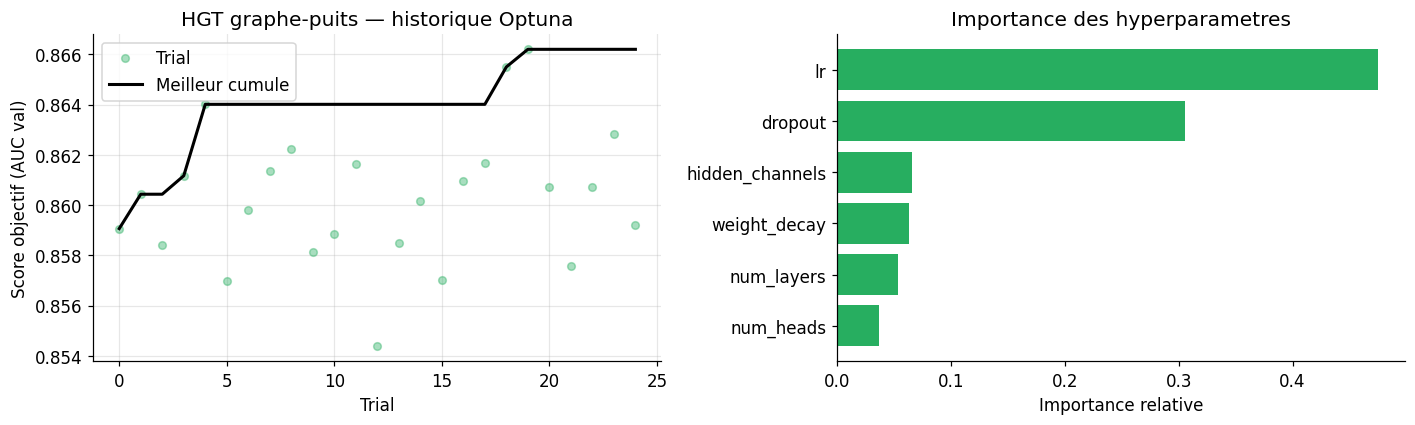

In [18]:
if TORCH_GEOMETRIC_AVAILABLE:
    def objective_hgt(trial):
        m = HGT_Classifier(metadata,
            hidden_channels=trial.suggest_categorical("hidden_channels", [64, 128, 256]),
            num_heads=trial.suggest_categorical("num_heads", [2, 4]),
            num_layers=trial.suggest_int("num_layers", 1, 3),
            dropout=trial.suggest_float("dropout", 0.1, 0.5)).to(device)
        _, h = train_hgt(m, data, epochs=max(60, EPOCHS_HGT//2),
                         lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
                         weight_decay=trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
                         es_patience=30, verbose=False)
        return max(h["val_auc"])
    study_hgt = optuna.create_study(direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_hgt.enqueue_trial({"hidden_channels": 128, "num_heads": 4, "num_layers": 2,
                             "dropout": 0.3, "lr": 3e-3, "weight_decay": 1e-5})
    study_hgt.optimize(objective_hgt, n_trials=_TRIALS["hgt"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
    bp = study_hgt.best_params
    print("Meilleurs params HGT :", bp)
    optuna_history_fig(study_hgt, "HGT graphe-puits", "fig05_optuna_hgt.png", color="#27ae60")

  epoch   1/300 | loss 0.6783 | val_auc 0.7221 | val_f1 0.6491
  epoch  10/300 | loss 0.4313 | val_auc 0.8485 | val_f1 0.7288
  epoch  20/300 | loss 0.3617 | val_auc 0.8585 | val_f1 0.7549
  epoch  30/300 | loss 0.2945 | val_auc 0.8417 | val_f1 0.7512
  epoch  40/300 | loss 0.2638 | val_auc 0.8461 | val_f1 0.7616
  epoch  50/300 | loss 0.2361 | val_auc 0.8461 | val_f1 0.7523
  epoch  60/300 | loss 0.2246 | val_auc 0.8449 | val_f1 0.7627
  epoch  70/300 | loss 0.2172 | val_auc 0.8436 | val_f1 0.7631
  early stop epoch 71 (pas d'amelioration depuis 50 epochs)
Termine — meilleur val AUC : 0.8586


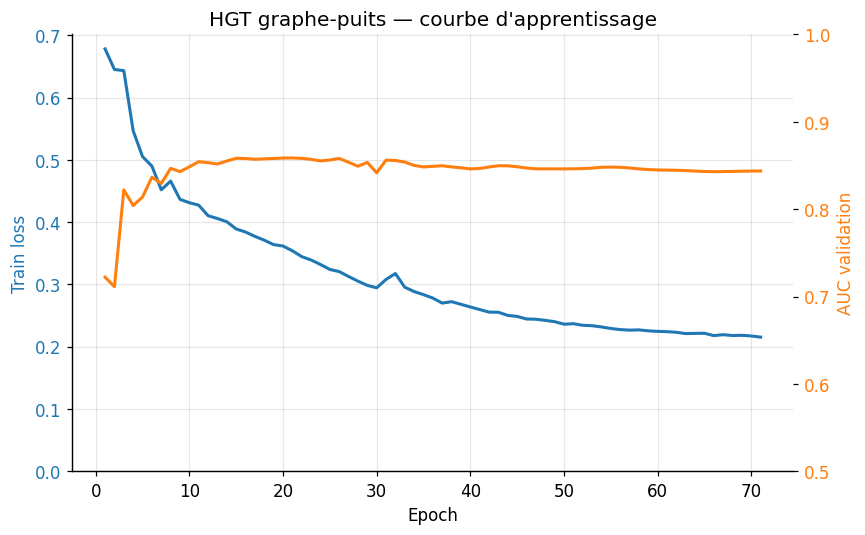

In [19]:
if TORCH_GEOMETRIC_AVAILABLE:
    hgt_model = HGT_Classifier(metadata, hidden_channels=bp["hidden_channels"],
        num_heads=bp["num_heads"], num_layers=bp["num_layers"], dropout=bp["dropout"]).to(device)
    with torch.no_grad():
        _xd, _ed = graph_tensors(data); _ = hgt_model(_xd, _ed)
    hgt_model, hgt_hist = train_hgt(hgt_model, data, epochs=EPOCHS_HGT,
        lr=bp["lr"], weight_decay=bp["weight_decay"], verbose=True)

    ep = range(1, len(hgt_hist["train_loss"])+1)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(ep, hgt_hist["train_loss"], color="tab:blue", lw=2, label="Train loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Train loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue"); ax1.grid(alpha=.3); ax1.set_ylim(bottom=0)
    ax2 = ax1.twinx(); ax2.plot(ep, hgt_hist["val_auc"], color="tab:orange", lw=2, label="Val AUC")
    ax2.set_ylabel("AUC validation", color="tab:orange"); ax2.tick_params(axis="y", labelcolor="tab:orange")
    ax2.set_ylim(0.5, 1.0); ax1.set_title("HGT graphe-puits — courbe d'apprentissage")
    plt.tight_layout(); savefig(fig, "fig06_hgt_learning_curve.png"); plt.show()

────────────────────────────────────────────────────
  HGT graphe-puits
────────────────────────────────────────────────────
  roc_auc             : 0.9006
  avg_precision       : 0.8845
  recall              : 0.7862
  precision           : 0.7941
  f1                  : 0.7901
  balanced_accuracy   : 0.8136
  accuracy            : 0.8170


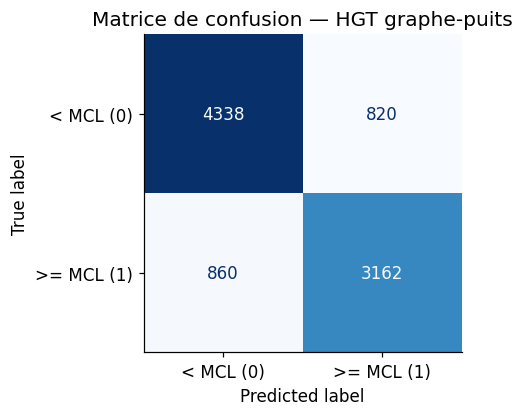

In [20]:
if TORCH_GEOMETRIC_AVAILABLE:
    hgt_model.eval()
    with torch.no_grad():
        xd, ed = graph_tensors(data)
        proba_all = F.softmax(hgt_model(xd, ed), dim=1)[:, 1].cpu().numpy()
    y_proba_hgt = proba_all[idx_test]
    y_pred_hgt  = (y_proba_hgt > 0.5).astype(int)
    m_hgt = evaluate("HGT graphe-puits", y_test, y_pred_hgt, y_proba_hgt)
    plot_confusion("HGT graphe-puits", y_test, y_pred_hgt, "fig07_hgt_confusion.png")

## Modèle 4 — Embedding Fusion (features + embeddings HGT → XGBoost)

Embeddings HGT 256D -> PCA 72D (variance 95.1%)


  0%|          | 0/20 [00:00<?, ?it/s]

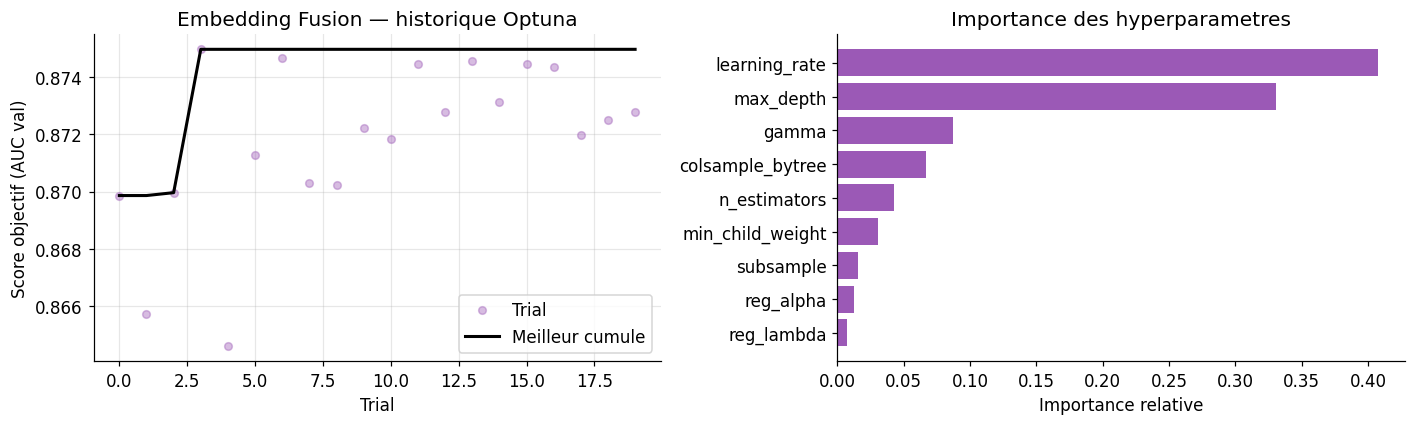

────────────────────────────────────────────────────
  Embedding Fusion
────────────────────────────────────────────────────
  roc_auc             : 0.9122
  avg_precision       : 0.8973
  recall              : 0.7815
  precision           : 0.8151
  f1                  : 0.7979
  balanced_accuracy   : 0.8216
  accuracy            : 0.8266


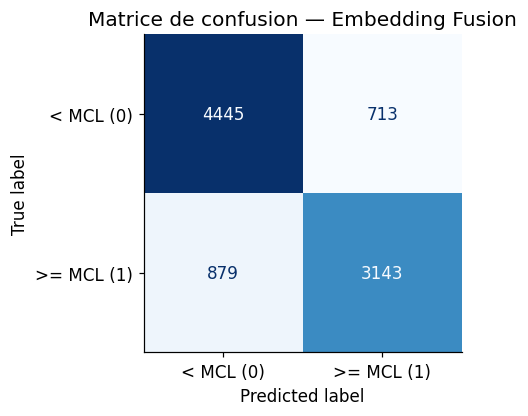

In [21]:
if TORCH_GEOMETRIC_AVAILABLE:
    with torch.no_grad():
        emb_all = hgt_model(xd, ed, return_embeddings=True).cpu().numpy()
    pca_fus = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(emb_all[idx_train])
    emb_p = pca_fus.transform(emb_all)
    n_emb = emb_p.shape[1]
    print(f"Embeddings HGT {emb_all.shape[1]}D -> PCA {n_emb}D "
          f"(variance {pca_fus.explained_variance_ratio_.sum():.1%})")

    X_fus = np.concatenate([X_all_proc, emb_p], axis=1)
    Xtr_fus, Xva_fus, Xte_fus = (X_fus[i] for i in (idx_train, idx_val, idx_test))
    fusion_names = proc_cols + [f"HGT_emb_{j}" for j in range(n_emb)]

    def objective_fusion(trial):
        p = dict(n_estimators=trial.suggest_int("n_estimators", 150, 800),
                 max_depth=trial.suggest_int("max_depth", 3, 12),
                 learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                 subsample=trial.suggest_float("subsample", 0.5, 1.0),
                 colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
                 min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
                 gamma=trial.suggest_float("gamma", 0.0, 1.0),
                 reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
                 reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 2.0, log=True),
                 scale_pos_weight=scale_pos, tree_method="hist",
                 random_state=RANDOM_STATE, eval_metric="auc", verbosity=0)
        c = xgb.XGBClassifier(**p, early_stopping_rounds=40)
        c.fit(Xtr_fus, y_train, eval_set=[(Xva_fus, y_val)], verbose=False)
        return roc_auc_score(y_val, c.predict_proba(Xva_fus)[:, 1])

    study_fus = optuna.create_study(direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_fus.optimize(objective_fusion, n_trials=_TRIALS["fusion"], timeout=OPTUNA_TIMEOUT, show_progress_bar=True)
    optuna_history_fig(study_fus, "Embedding Fusion", "fig08_optuna_fusion.png", color="#9b59b6")

    p_fus = {**study_fus.best_params, "scale_pos_weight": scale_pos, "tree_method": "hist",
             "random_state": RANDOM_STATE, "eval_metric": "auc", "verbosity": 0}
    xgb_fusion = xgb.XGBClassifier(**p_fus, early_stopping_rounds=50)
    xgb_fusion.fit(Xtr_fus, y_train, eval_set=[(Xva_fus, y_val)], verbose=False)
    y_pred_fus  = xgb_fusion.predict(Xte_fus)
    y_proba_fus = xgb_fusion.predict_proba(Xte_fus)[:, 1]
    m_fus = evaluate("Embedding Fusion", y_test, y_pred_fus, y_proba_fus)
    plot_confusion("Embedding Fusion", y_test, y_pred_fus, "fig09_fusion_confusion.png")

## Modèle 5 — Stacking honnête (méta-modèle ajusté sur la validation)

Correlation des predictions test (RF/XGB/HGT) :
        RF    XGB    HGT
RF   1.000  0.963  0.896
XGB  0.963  1.000  0.914
HGT  0.896  0.914  1.000

Poids du meta-modele (RF, XGB, HGT) : [-0.056  0.642  0.077]
────────────────────────────────────────────────────
  Stacking
────────────────────────────────────────────────────
  roc_auc             : 0.9137
  avg_precision       : 0.8984
  recall              : 0.7601
  precision           : 0.8431
  f1                  : 0.7994
  balanced_accuracy   : 0.8249
  accuracy            : 0.8329


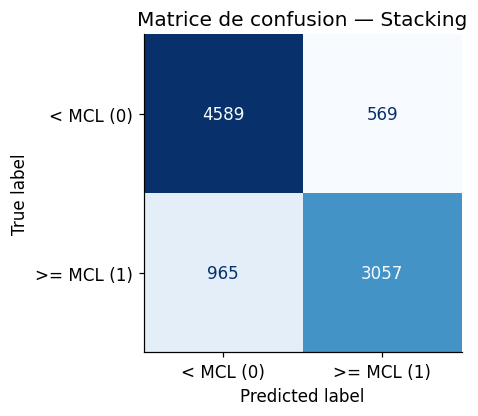


Moyenne ponderee (poids val [0.   0.86 0.14]) — AUC test : 0.9134


In [22]:
if TORCH_GEOMETRIC_AVAILABLE:
    P_val  = np.column_stack([rf.predict_proba(X_val_proc)[:, 1],
                              xgb_model.predict_proba(X_val_proc)[:, 1],
                              proba_all[idx_val]])
    P_test = np.column_stack([y_proba_rf, y_proba_xgb, y_proba_hgt])

    corr = np.corrcoef(P_test.T)
    print("Correlation des predictions test (RF/XGB/HGT) :")
    print(pd.DataFrame(corr, index=["RF","XGB","HGT"], columns=["RF","XGB","HGT"]).round(3).to_string())

    eps = 1e-6
    logit = lambda p: np.log((p + eps) / (1 - p + eps))
    meta_lr = LogisticRegression(max_iter=1000).fit(logit(P_val), y_val)
    y_proba_stk = meta_lr.predict_proba(logit(P_test))[:, 1]
    y_pred_stk = (y_proba_stk > 0.5).astype(int)
    print("\nPoids du meta-modele (RF, XGB, HGT) :", np.round(meta_lr.coef_[0], 3))
    m_stk = evaluate("Stacking", y_test, y_pred_stk, y_proba_stk)
    plot_confusion("Stacking", y_test, y_pred_stk, "fig10_stacking_confusion.png")

    best_w, best_auc = None, 0
    for w1 in np.linspace(0, 1, 21):
        for w2 in np.linspace(0, 1 - w1, int(21*(1-w1))+1):
            w = np.array([w1, w2, 1 - w1 - w2])
            auc = roc_auc_score(y_val, P_val @ w)
            if auc > best_auc:
                best_auc, best_w = auc, w
    print(f"\nMoyenne ponderee (poids val {np.round(best_w,2)}) — "
          f"AUC test : {roc_auc_score(y_test, P_test @ best_w):.4f}")

## Comparaison finale

                  ROC-AUC      AP  Rappel  Precision      F1  Bal.Acc  Accuracy
Modele                                                                         
HGT graphe-puits   0.9006  0.8845  0.7862     0.7941  0.7901   0.8136    0.8170
Random Forest      0.8985  0.8813  0.7248     0.8302  0.7739   0.8046    0.8145
XGBoost            0.9116  0.8961  0.7499     0.8389  0.7919   0.8188    0.8273
Embedding Fusion   0.9122  0.8973  0.7815     0.8151  0.7979   0.8216    0.8266
Stacking           0.9137  0.8984  0.7601     0.8431  0.7994   0.8249    0.8329

Meilleur modele (AUC) : Stacking  (AUC=0.9137)
Rappel NB11 (graphe echantillons) : HGT 0.8425 | RF 0.8910 | XGB 0.9059 | Fusion 0.8808 | Stacking 0.9061


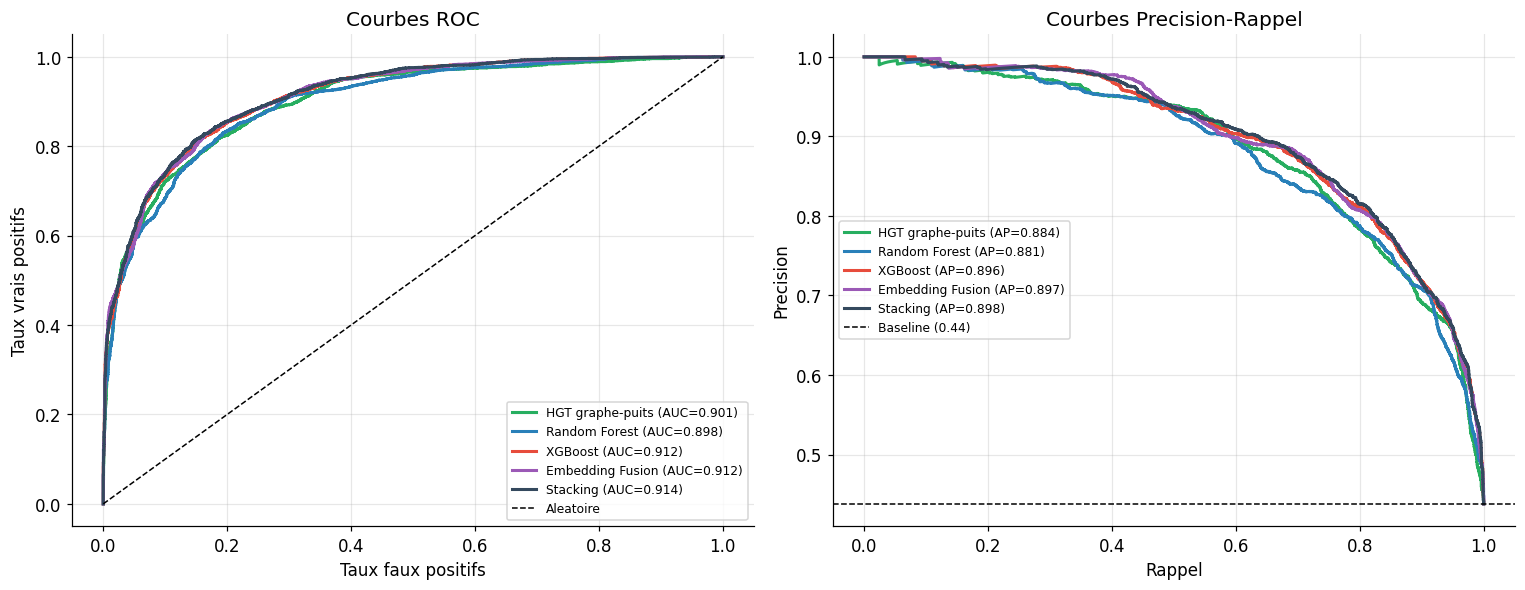

In [23]:
ORDER = ["HGT graphe-puits", "Random Forest", "XGBoost", "Embedding Fusion", "Stacking"]
ORDER = [m for m in ORDER if m in RESULTS]
COLORS = {"HGT graphe-puits": "#27ae60", "Random Forest": "#2980b9", "XGBoost": "#e74c3c",
          "Embedding Fusion": "#9b59b6", "Stacking": "#34495e"}

comp = pd.DataFrame([{
    "Modele": m,
    "ROC-AUC": RESULTS[m]["metrics"]["roc_auc"],
    "AP": RESULTS[m]["metrics"]["avg_precision"],
    "Rappel": RESULTS[m]["metrics"]["recall"],
    "Precision": RESULTS[m]["metrics"]["precision"],
    "F1": RESULTS[m]["metrics"]["f1"],
    "Bal.Acc": RESULTS[m]["metrics"]["balanced_accuracy"],
    "Accuracy": RESULTS[m]["metrics"]["accuracy"],
} for m in ORDER]).set_index("Modele")
comp.to_csv(RES_DIR / "comparaison_modeles.csv")
print(comp.round(4).to_string())
best = comp["ROC-AUC"].idxmax()
print(f"\nMeilleur modele (AUC) : {best}  (AUC={comp.loc[best,'ROC-AUC']:.4f})")
print("Rappel NB11 (graphe echantillons) : HGT 0.8425 | RF 0.8910 | XGB 0.9059 | "
      "Fusion 0.8808 | Stacking 0.9061")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
prev = y_test.mean()
for m in ORDER:
    pr = RESULTS[m]["y_proba"]; c = COLORS[m]
    fpr, tpr, _ = roc_curve(y_test, pr)
    ax1.plot(fpr, tpr, lw=2, color=c, label=f"{m} (AUC={RESULTS[m]['metrics']['roc_auc']:.3f})")
    p, r, _ = precision_recall_curve(y_test, pr)
    ax2.plot(r, p, lw=2, color=c, label=f"{m} (AP={RESULTS[m]['metrics']['avg_precision']:.3f})")
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatoire")
ax2.axhline(prev, color="k", ls="--", lw=1, label=f"Baseline ({prev:.2f})")
ax1.set(xlabel="Taux faux positifs", ylabel="Taux vrais positifs", title="Courbes ROC")
ax2.set(xlabel="Rappel", ylabel="Precision", title="Courbes Precision-Rappel")
ax1.legend(fontsize=8); ax2.legend(fontsize=8); ax1.grid(alpha=.3); ax2.grid(alpha=.3)
plt.tight_layout(); savefig(fig, "fig11_roc_pr_all.png"); plt.show()

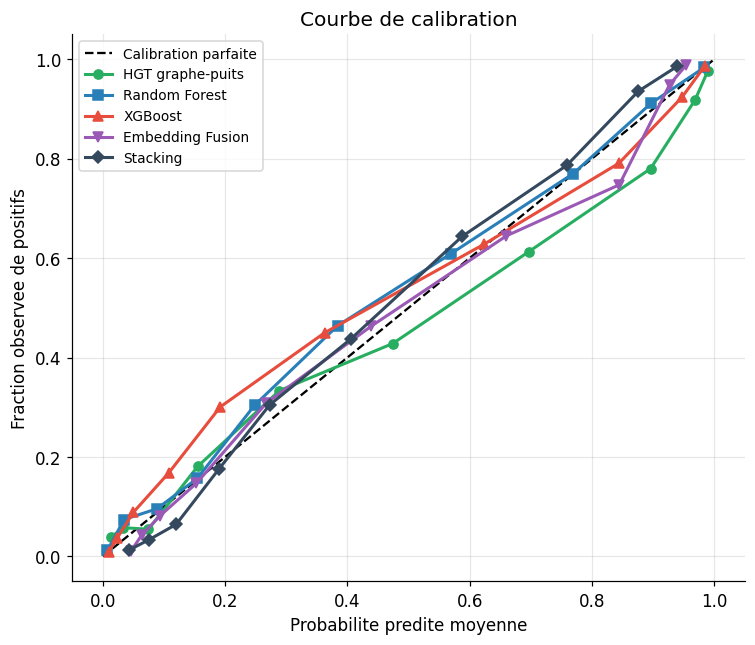

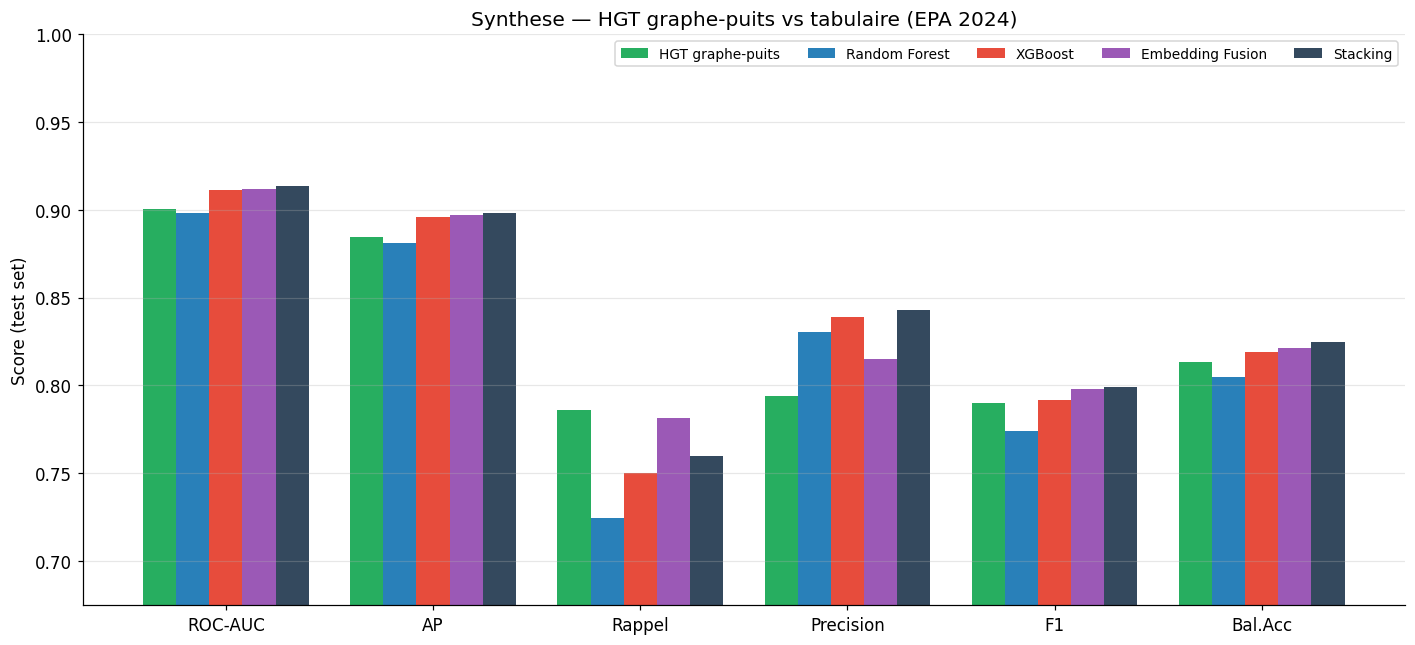

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", label="Calibration parfaite")
for m, mk in zip(ORDER, ["o-", "s-", "^-", "v-", "D-"]):
    fr, mp = calibration_curve(y_test, RESULTS[m]["y_proba"], n_bins=10, strategy="quantile")
    ax.plot(mp, fr, mk, color=COLORS[m], lw=2, label=m)
ax.set(xlabel="Probabilite predite moyenne", ylabel="Fraction observee de positifs",
       title="Courbe de calibration")
ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); savefig(fig, "fig12_calibration_all.png"); plt.show()

metrics = ["roc_auc", "avg_precision", "recall", "precision", "f1", "balanced_accuracy"]
labels = ["ROC-AUC", "AP", "Rappel", "Precision", "F1", "Bal.Acc"]
x = np.arange(len(labels)); w = 0.8 / len(ORDER)
fig, ax = plt.subplots(figsize=(13, 6))
for i, m in enumerate(ORDER):
    vals = [RESULTS[m]["metrics"][k] for k in metrics]
    ax.bar(x + i*w - 0.4 + w/2, vals, w, label=m, color=COLORS[m])
allv = [RESULTS[m]["metrics"][k] for m in ORDER for k in metrics]
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(max(0, min(allv) - 0.05), 1.0)
ax.set_ylabel("Score (test set)"); ax.set_title("Synthese — HGT graphe-puits vs tabulaire (EPA 2024)")
ax.legend(fontsize=9, ncol=len(ORDER)); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); savefig(fig, "fig13_dashboard.png"); plt.show()

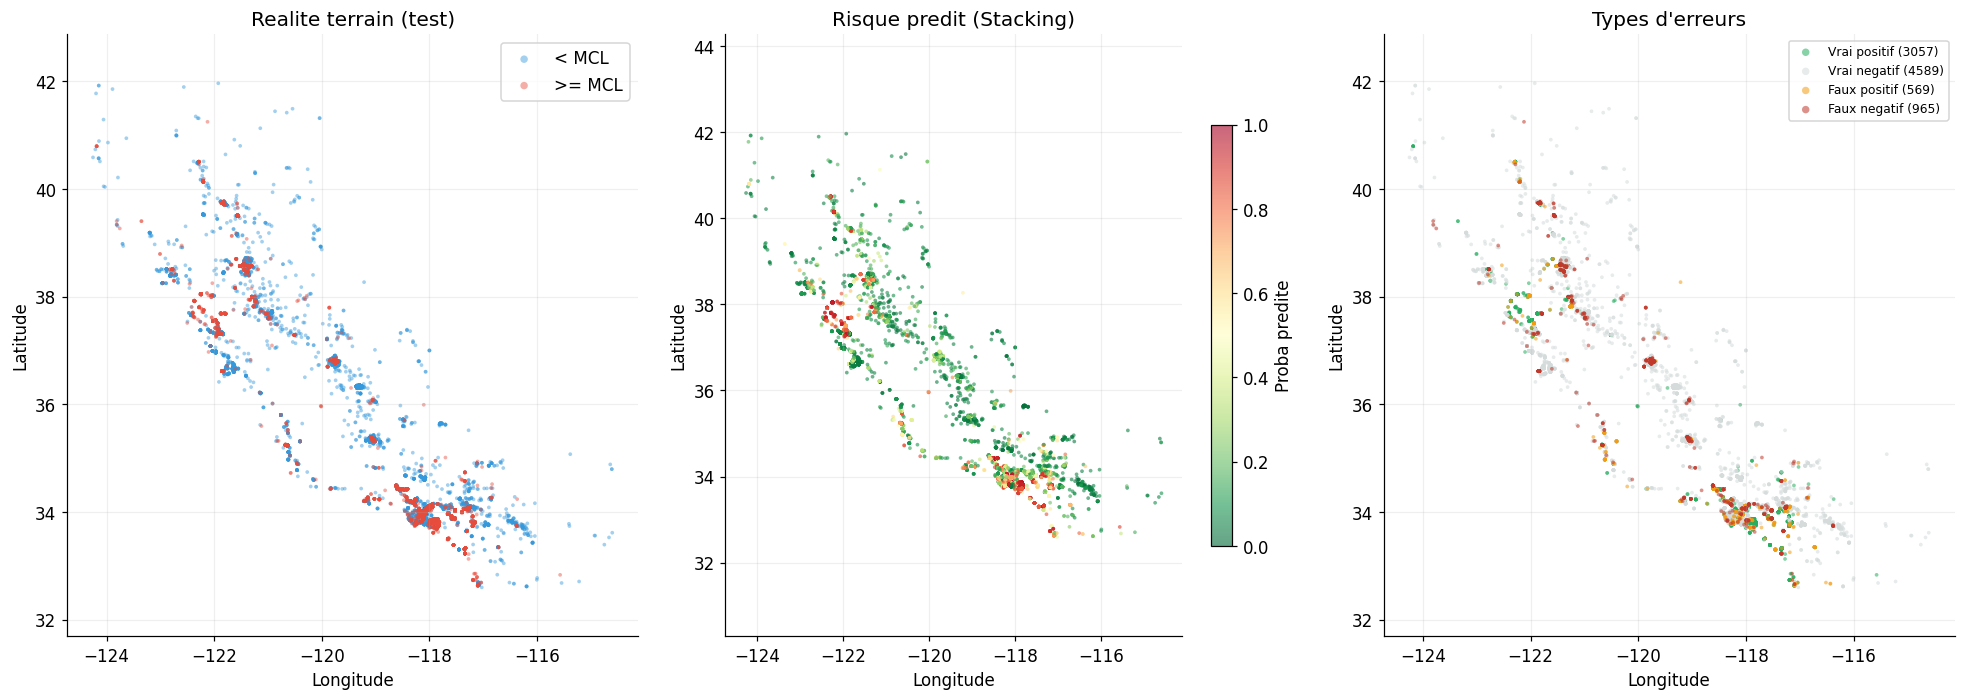

In [25]:
if {"latitude", "longitude"}.issubset(df.columns):
    coords = df.iloc[idx_test][["longitude", "latitude"]].copy()
    coords["y_true"] = y_test
    coords["proba"]  = RESULTS[best]["y_proba"]
    coords["y_pred"] = RESULTS[best]["y_pred"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
    for lab, c, mlab in [(0, "#3498db", "< MCL"), (1, "#e74c3c", ">= MCL")]:
        s = coords[coords.y_true == lab]
        axes[0].scatter(s.longitude, s.latitude, s=6, c=c, alpha=.45, label=mlab, edgecolors="none")
    axes[0].set_title("Realite terrain (test)"); axes[0].legend(markerscale=2)
    sc = axes[1].scatter(coords.longitude, coords.latitude, s=6, c=coords.proba,
                         cmap="RdYlGn_r", vmin=0, vmax=1, alpha=.6, edgecolors="none")
    plt.colorbar(sc, ax=axes[1], shrink=.7, label="Proba predite")
    axes[1].set_title(f"Risque predit ({best})")
    conds = [(coords.y_true==1)&(coords.y_pred==1), (coords.y_true==0)&(coords.y_pred==0),
             (coords.y_true==0)&(coords.y_pred==1), (coords.y_true==1)&(coords.y_pred==0)]
    labs = ["Vrai positif", "Vrai negatif", "Faux positif", "Faux negatif"]
    coords["err"] = np.select(conds, labs, default="?")
    pal = {"Vrai positif":"#27ae60","Vrai negatif":"#d5dbdb","Faux positif":"#f39c12","Faux negatif":"#c0392b"}
    for cat, c in pal.items():
        s = coords[coords.err == cat]
        axes[2].scatter(s.longitude, s.latitude, s=6, c=c, alpha=.55, label=f"{cat} ({len(s)})", edgecolors="none")
    axes[2].set_title("Types d'erreurs"); axes[2].legend(markerscale=2, fontsize=8)
    for ax in axes:
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_aspect("equal", "datalim"); ax.grid(alpha=.2)
    plt.tight_layout(); savefig(fig, "fig14_map_predictions.png"); plt.show()

## Interprétation — importance des features et concordance entre modèles

Figures reprises des notebooks 09/10 (banc d'interprétation) pour le rapport final :
SHAP des modèles à arbres, importance du HGT par ses poids d'entrée, et concordance des
rangs d'importance entre les trois familles (les modèles « regardent »-ils les mêmes features ?).

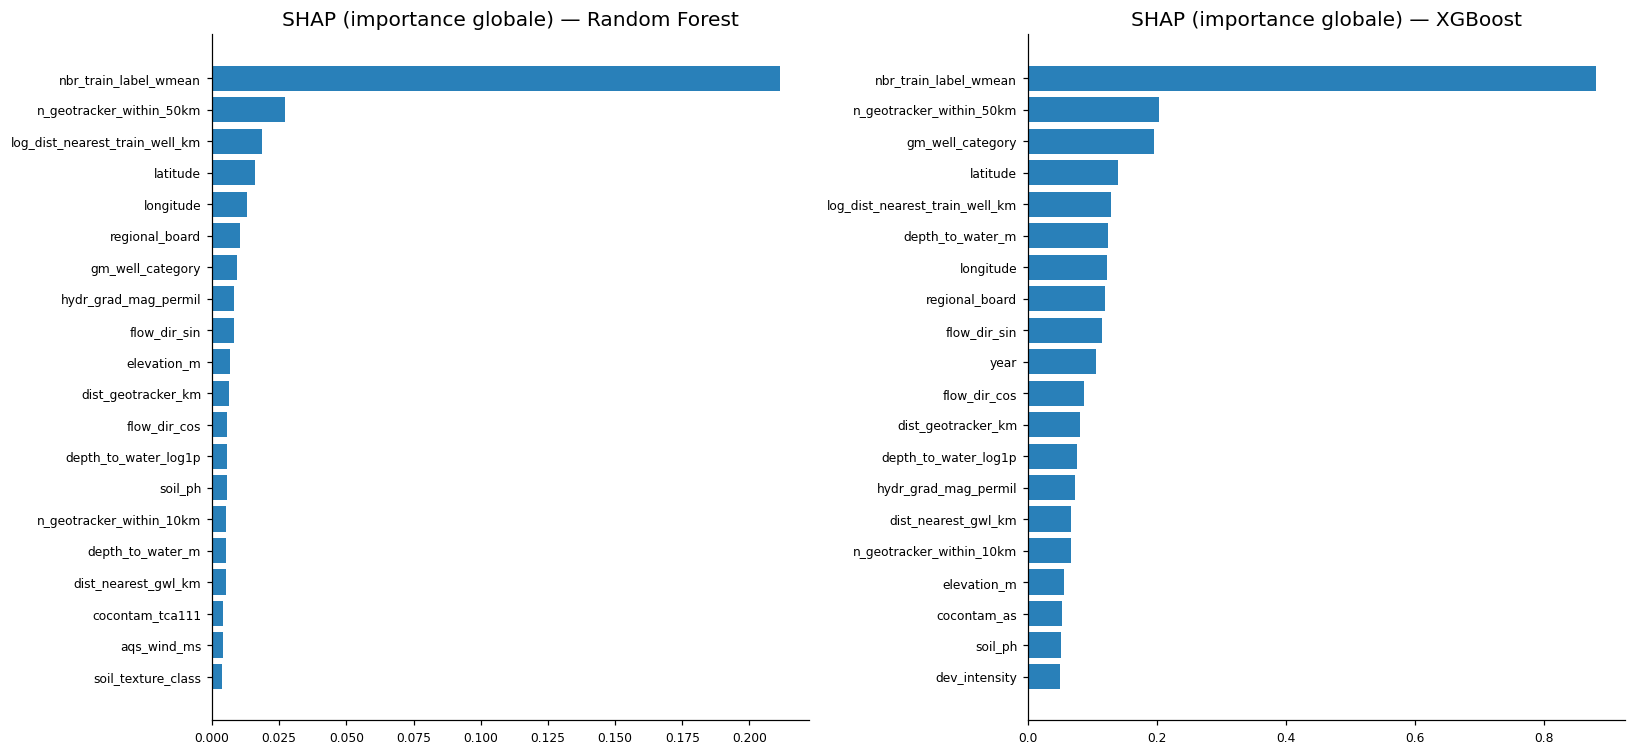

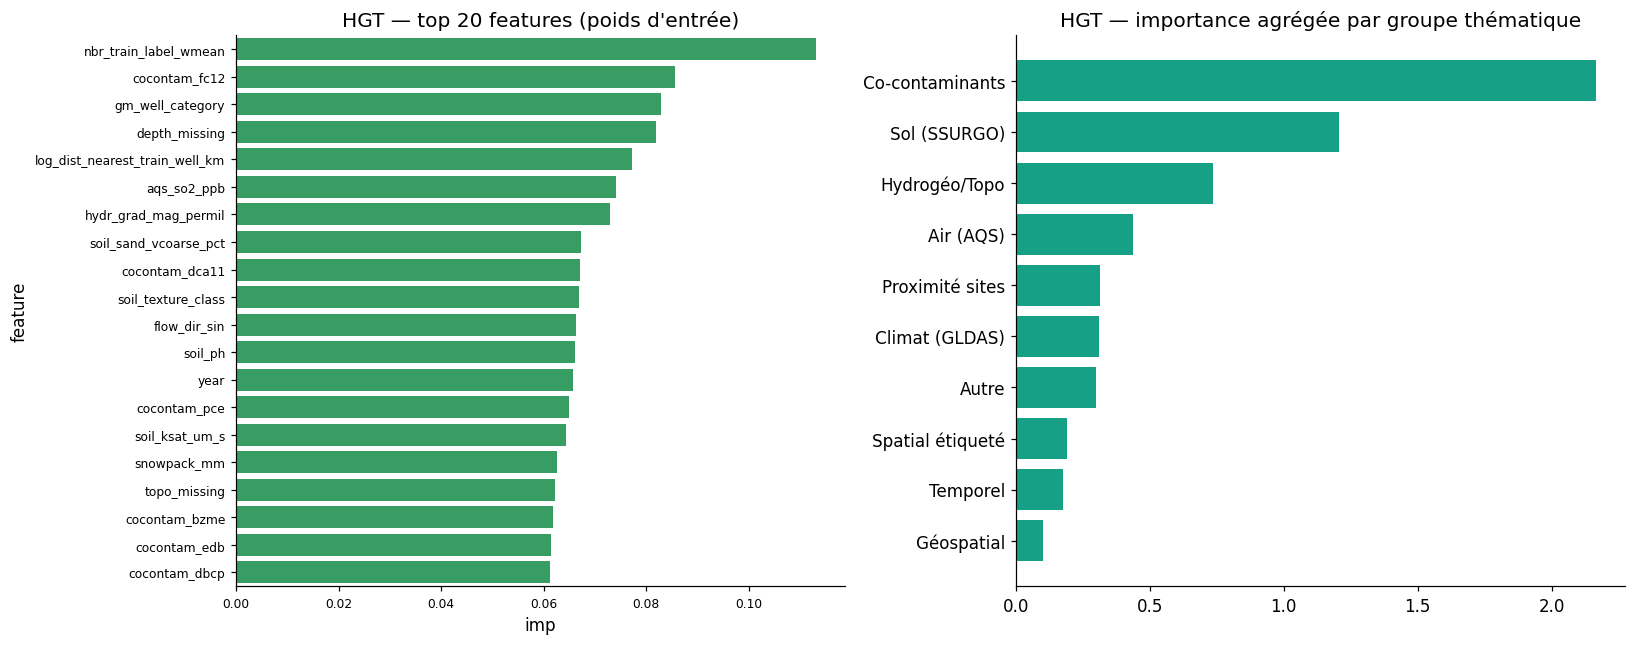

Concordance rangs RF vs XGB : Spearman ρ = +0.118 | RF vs HGT : +0.118 | XGB vs HGT : +0.132


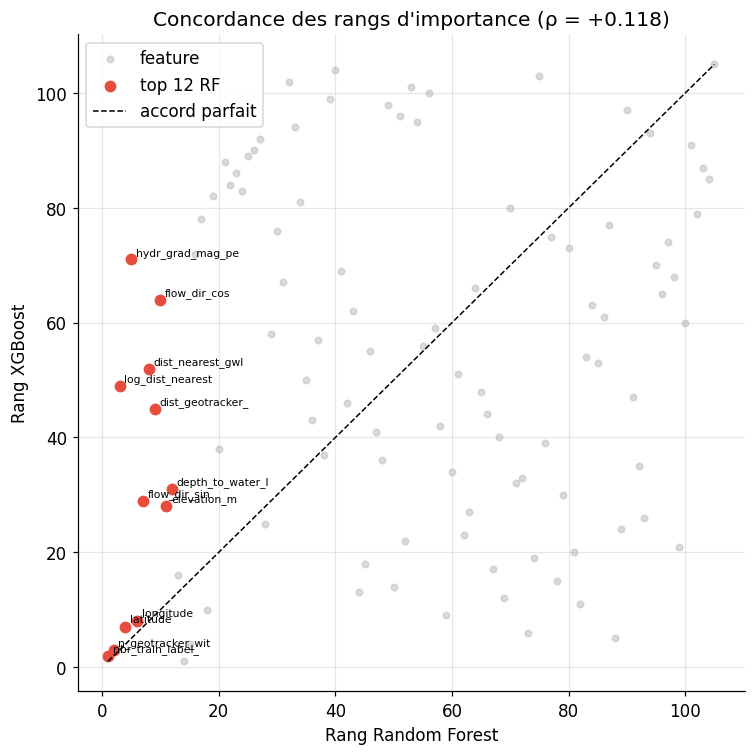

In [26]:
if RUN_INTERPRET:
    # regroupement thematique des features (pour agreger l'importance HGT)
    def _feat_group(c):
        if c in ("latitude", "longitude"): return "Géospatial"
        if c.startswith("cocontam_"): return "Co-contaminants"
        if c.startswith("soil_"): return "Sol (SSURGO)"
        if c.startswith("aqs_"): return "Air (AQS)"
        if any(c.startswith(p) for p in ("n_geotracker", "dist_geotracker")) or "geotracker" in c: return "Proximité sites"
        if any(k in c for k in ("depth", "dtw", "gwl", "hydr_grad", "flow_dir", "elevation", "topo", "dev_intensity", "lc_")): return "Hydrogéo/Topo"
        if any(k in c for k in ("rainfall", "et_mm", "runoff", "soil_moi", "temp_c", "snow", "root_zone")): return "Climat (GLDAS)"
        if c in ("year", "month", "season"): return "Temporel"
        if c in SPATIAL_LABEL_NAMES: return "Spatial étiqueté"
        return "Autre"

    # ── SHAP arbres (bar) ────────────────────────────────────────────────
    try:
        import shap
        _rng = np.random.RandomState(RANDOM_STATE)
        _idx = _rng.choice(len(X_test_proc), min(SHAP_SAMPLE, len(X_test_proc)), replace=False)
        fig, axes = plt.subplots(1, 2, figsize=(15, 7))
        for ax, (mdl, ttl) in zip(axes, [(rf, "Random Forest"), (xgb_model, "XGBoost")]):
            sv = shap.TreeExplainer(mdl).shap_values(X_test_proc[_idx])
            if isinstance(sv, list): sv = sv[1]
            if getattr(sv, "ndim", 2) == 3: sv = sv[..., 1]
            imp = np.abs(sv).mean(0)
            order = np.argsort(imp)[-20:]
            ax.barh([proc_cols[i] for i in order], imp[order], color="#2980b9")
            ax.set_title(f"SHAP (importance globale) — {ttl}"); ax.tick_params(labelsize=8)
        plt.tight_layout(); savefig(fig, "fig16_shap_arbres.png"); plt.show()
    except Exception as e:
        print("SHAP arbres indisponible :", e)

    # ── Importance HGT (poids d'entree du noeud sample) + agregation groupe ──
    if TORCH_GEOMETRIC_AVAILABLE:
        with torch.no_grad():
            w = hgt_model.lin_dict["sample"].weight.detach().cpu().numpy()
        imp_hgt = np.abs(w).mean(0)
        fi_hgt = pd.DataFrame({"feature": proc_cols, "imp": imp_hgt}).sort_values("imp", ascending=False)
        fi_hgt["groupe"] = fi_hgt["feature"].map(_feat_group)
        grp = fi_hgt.groupby("groupe")["imp"].sum().sort_values(ascending=False)
        fig, ax = plt.subplots(1, 2, figsize=(15, 6))
        sns.barplot(data=fi_hgt.head(20), x="imp", y="feature", color="#27ae60", ax=ax[0])
        ax[0].set_title("HGT — top 20 features (poids d'entrée)"); ax[0].tick_params(labelsize=8)
        ax[1].barh(grp.index[::-1], grp.values[::-1], color="#16a085")
        ax[1].set_title("HGT — importance agrégée par groupe thématique")
        plt.tight_layout(); savefig(fig, "fig17_hgt_importance.png"); plt.show()

    # ── Concordance des rangs d'importance RF / XGB / HGT ────────────────
    try:
        from scipy.stats import spearmanr
        fi_rf = pd.DataFrame({"feature": proc_cols, "r_rf": rf.feature_importances_}).sort_values("r_rf", ascending=False).reset_index(drop=True)
        fi_rf["rank_rf"] = fi_rf.index + 1
        _gain = xgb_model.get_booster().get_score(importance_type="gain")
        fi_xg = pd.DataFrame({"feature": proc_cols, "r_xg": [_gain.get(f"f{i}", 0.0) for i in range(len(proc_cols))]}).sort_values("r_xg", ascending=False).reset_index(drop=True)
        fi_xg["rank_xg"] = fi_xg.index + 1
        M = fi_rf[["feature", "rank_rf"]].merge(fi_xg[["feature", "rank_xg"]], on="feature")
        rho_rx = spearmanr(M.rank_rf, M.rank_xg).correlation
        line = f"Concordance rangs RF vs XGB : Spearman ρ = {rho_rx:+.3f}"
        if TORCH_GEOMETRIC_AVAILABLE:
            fh = fi_hgt.reset_index(drop=True).copy(); fh["rank_hg"] = fh.index + 1
            M = M.merge(fh[["feature", "rank_hg"]], on="feature")
            rho_rh = spearmanr(M.rank_rf, M.rank_hg).correlation
            rho_xh = spearmanr(M.rank_xg, M.rank_hg).correlation
            line += f" | RF vs HGT : {rho_rh:+.3f} | XGB vs HGT : {rho_xh:+.3f}"
        print(line)
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.scatter(M.rank_rf, M.rank_xg, s=18, c="#bdc3c7", alpha=.6, label="feature")
        top = M.sort_values("rank_rf").head(12)
        ax.scatter(top.rank_rf, top.rank_xg, s=45, c="#e74c3c", label="top 12 RF")
        for _, r in top.iterrows():
            ax.annotate(r["feature"][:16], (r.rank_rf, r.rank_xg), fontsize=7, xytext=(3,3), textcoords="offset points")
        lim = len(proc_cols); ax.plot([1, lim], [1, lim], "k--", lw=1, label="accord parfait")
        ax.set(xlabel="Rang Random Forest", ylabel="Rang XGBoost",
               title=f"Concordance des rangs d'importance (ρ = {rho_rx:+.3f})")
        ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); savefig(fig, "fig18_concordance_rangs.png"); plt.show()
    except Exception as e:
        print("Concordance indisponible :", e)
else:
    print("Interprétation desactivee (RUN_INTERPRET=False).")

## Interprétation — structure apprise du graphe

Projection 2D des embeddings HGT (séparation des classes apprise), voisinage hétérogène
d'un puits contaminé (nœuds `well`, `source`, `subbasin`, voisins spatiaux et advectifs), et
tableau des nœuds/arêtes du graphe transductif.

NŒUDS
       noeud     n  dim_x
     sample 46338    105
       well 11333    106
     source   463      3
   subbasin   238      3
geo_cluster    20      2

ARÊTES
                             relation  n_aretes
          sample -[from_well]-> well     46338
         well -[has_sample]-> sample     46338
           well -[near_0_2km]-> well    141174
          well -[near_2_10km]-> well     71724
         well -[near_10_30km]-> well     12542
             well -[flows_to]-> well     73267
 well -[near_source_0_10km]-> source     28076
   source -[source_of_0_10km]-> well     28076
well -[near_source_10_50km]-> source     25605
  source -[source_of_10_50km]-> well     25605
         well -[in_basin]-> subbasin     11333
         subbasin -[basin_of]-> well     11333
    well -[located_in]-> geo_cluster     11333
      geo_cluster -[contains]-> well     11333


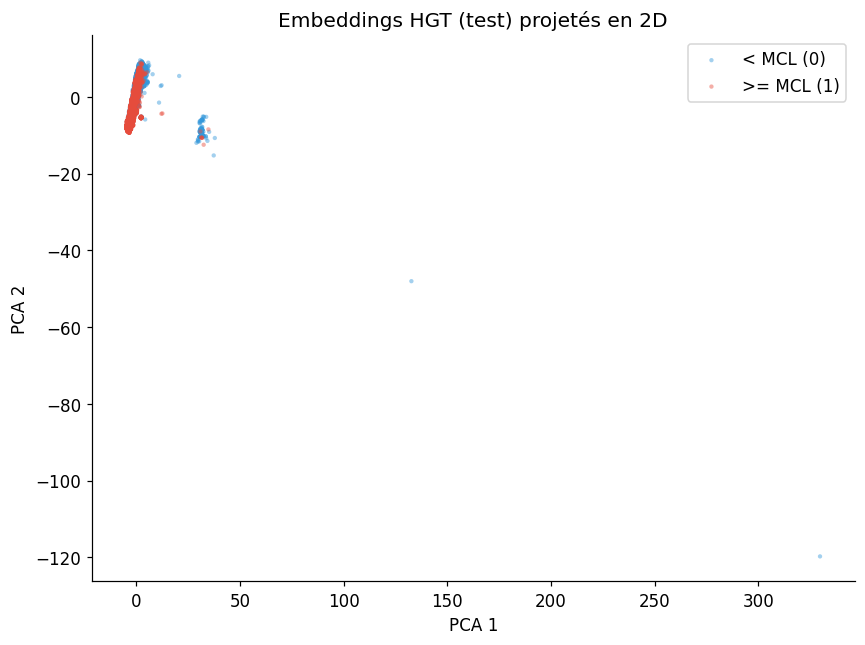

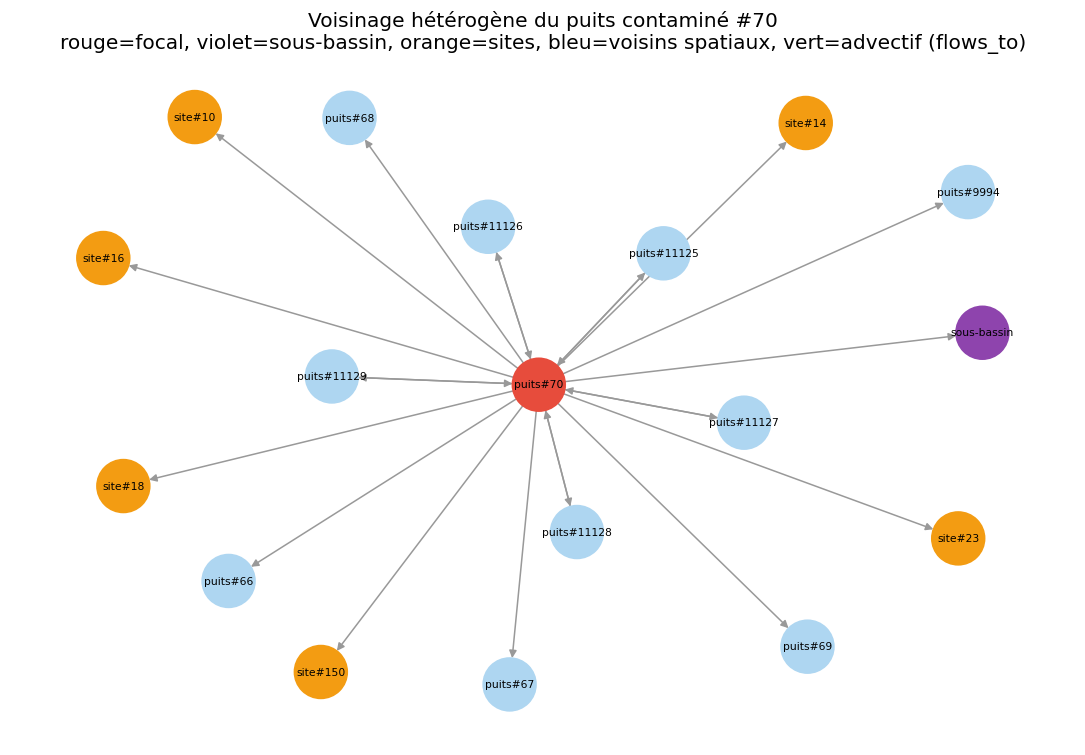

In [27]:
if RUN_INTERPRET and TORCH_GEOMETRIC_AVAILABLE:
    # ── Tableau noeuds / aretes ──────────────────────────────────────────
    nodes_tbl = pd.DataFrame([{"noeud": nt, "n": data[nt].num_nodes,
                               "dim_x": (data[nt].x.shape[1] if "x" in data[nt] else 0)}
                              for nt in data.node_types])
    edges_tbl = pd.DataFrame([{"relation": f"{a} -[{b}]-> {c}", "n_aretes": data[a, b, c].edge_index.shape[1]}
                              for a, b, c in data.edge_types])
    print("NŒUDS\n", nodes_tbl.to_string(index=False))
    print("\nARÊTES\n", edges_tbl.to_string(index=False))
    edges_tbl.to_csv(RES_DIR / "graphe_aretes.csv", index=False)

    # ── Embeddings HGT en 2D (PCA) colores par classe ───────────────────
    try:
        p2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(emb_all[idx_test])
        fig, ax = plt.subplots(figsize=(8, 6))
        for lab, col, nm in [(0, "#3498db", "< MCL (0)"), (1, "#e74c3c", ">= MCL (1)")]:
            m = y_test == lab
            ax.scatter(p2[m, 0], p2[m, 1], s=8, c=col, alpha=.45, label=nm, edgecolors="none")
        ax.set(xlabel="PCA 1", ylabel="PCA 2", title="Embeddings HGT (test) projetés en 2D")
        ax.legend(); plt.tight_layout(); savefig(fig, "fig19_embeddings_2d.png"); plt.show()
    except Exception as e:
        print("Embeddings 2D indisponibles :", e)

    # ── Ego-graph d'un puits contaminé ──────────────────────────────────
    try:
        import networkx as nx
        FOCAL = int(idx_test[np.where(y_test == 1)[0][0]])   # 1er echantillon test positif
        fw = int(winv[FOCAL])
        G = nx.DiGraph(); color = {}
        wn = f"puits#{fw}"; G.add_node(wn); color[wn] = "#e74c3c"
        # sous-bassin
        G.add_edge(wn, "sous-bassin"); color["sous-bassin"] = "#8e44ad"
        # sources proches
        if SOURCE_X is not None:
            for k in src_edges:
                s_, t_ = src_edges[k]
                for a, b in zip(s_, t_):
                    if a == fw:
                        sn = f"site#{b}"; G.add_edge(wn, sn); color[sn] = "#f39c12"
        # voisins spatiaux (bandes) et advectifs (flows_to)
        for band_i, (s_, t_) in enumerate(band_edges):
            for a, b in zip(s_, t_):
                if a == fw:
                    vn = f"puits#{b}"; G.add_edge(wn, vn); color.setdefault(vn, "#aed6f1")
        for a, b in zip(*flow_edges):
            if a == fw:
                vn = f"puits#{b}"; G.add_edge(vn, wn); color.setdefault(vn, "#16a085")  # amont -> focal
            elif b == fw:
                vn = f"puits#{a}"; G.add_edge(wn, vn); color.setdefault(vn, "#16a085")
        # limiter la taille
        if G.number_of_nodes() > 22:
            keep = [wn, "sous-bassin"] + [n for n in G.nodes() if n not in (wn, "sous-bassin")][:20]
            G = G.subgraph(keep).copy()
        fig, ax = plt.subplots(figsize=(10, 7))
        pos = nx.spring_layout(G, seed=RANDOM_STATE, k=0.9)
        nx.draw_networkx(G, pos, ax=ax, node_size=1200,
                         node_color=[color.get(n, "#cccccc") for n in G.nodes()],
                         font_size=7, edge_color="#999", arrows=True)
        ax.set_title(f"Voisinage hétérogène du puits contaminé #{fw}\n"
                     "rouge=focal, violet=sous-bassin, orange=sites, bleu=voisins spatiaux, vert=advectif (flows_to)")
        ax.axis("off"); plt.tight_layout(); savefig(fig, "fig20_ego_graph.png"); plt.show()
    except Exception as e:
        print("Ego-graph indisponible :", e)

## Interprétation — apport quantifié du message-passing

Pour un puits contaminé focal, on compare sa probabilité prédite avec le graphe complet vs.
en **coupant toutes les arêtes entrantes vers son nœud `well`** (le puits est alors isolé de
son voisinage : il ne reste que ses propres features). Δ proba = apport net du voisinage.

Puits focal #70 : proba AVEC graphe 0.434 | SANS (features seules) 0.426 | Δ = +0.008
AUC test — HGT complet 0.9006 | HGT features seules (sans graphe) 0.8885 | apport du message-passing = +0.0120


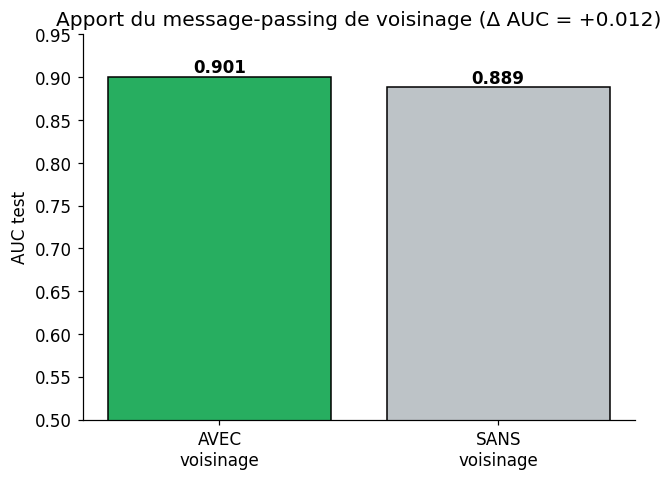

In [28]:
if RUN_INTERPRET and TORCH_GEOMETRIC_AVAILABLE:
    try:
        hgt_model.eval()
        xd, ed = graph_tensors(data)
        FOCAL = int(idx_test[np.where(y_test == 1)[0][0]]); fw = int(winv[FOCAL])
        # graphe isolé : retirer les aretes entrantes vers le noeud well focal
        # isole le sample focal : couper les aretes ENTRANTES vers lui (dst == FOCAL, type sample)
        # -> il ne recoit plus rien du graphe, seule sa projection h0 subsiste (informatif a toute
        #    profondeur, contrairement a couper le noeud well qui n'agit qu'a >=2 couches).
        ed_iso = {}
        for (a, b, c), ei in ed.items():
            if c == "sample":
                keep = ei[1] != FOCAL
                ed_iso[(a, b, c)] = ei[:, keep]
            else:
                ed_iso[(a, b, c)] = ei
        with torch.no_grad():
            p_full = F.softmax(hgt_model(xd, ed), 1)[FOCAL, 1].item()
            p_iso  = F.softmax(hgt_model(xd, ed_iso), 1)[FOCAL, 1].item()
        # global : couper TOUTES les aretes entrantes vers sample -> HGT features seules (via h0)
        with torch.no_grad():
            pf_all = F.softmax(hgt_model(xd, ed), 1)[:, 1].cpu().numpy()[idx_test]
        ed_iso_all = {}
        for (a, b, c), ei in ed.items():
            ed_iso_all[(a, b, c)] = ei[:, :0] if c == "sample" else ei
        with torch.no_grad():
            pi_all = F.softmax(hgt_model(xd, ed_iso_all), 1)[:, 1].cpu().numpy()[idx_test]
        auc_full = roc_auc_score(y_test, pf_all); auc_iso = roc_auc_score(y_test, pi_all)
        print(f"Puits focal #{fw} : proba AVEC graphe {p_full:.3f} | SANS (features seules) {p_iso:.3f} | Δ = {p_full-p_iso:+.3f}")
        print(f"AUC test — HGT complet {auc_full:.4f} | HGT features seules (sans graphe) {auc_iso:.4f} "
              f"| apport du message-passing = {auc_full-auc_iso:+.4f}")
        fig, ax = plt.subplots(figsize=(6, 4.5))
        ax.bar(["AVEC\nvoisinage", "SANS\nvoisinage"], [auc_full, auc_iso],
               color=["#27ae60", "#bdc3c7"], edgecolor="black")
        ax.set_ylim(0.5, max(0.95, auc_full+0.03)); ax.set_ylabel("AUC test")
        ax.set_title(f"Apport du message-passing de voisinage (Δ AUC = {auc_full-auc_iso:+.3f})")
        for i, v in enumerate([auc_full, auc_iso]):
            ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")
        plt.tight_layout(); savefig(fig, "fig21_apport_message_passing.png"); plt.show()
    except Exception as e:
        print("Ablation message-passing indisponible :", e)

## Évaluation honnête — CV spatiale par blocs **incluant le HGT**

La question centrale du mémoire : hors-zone, la mémorisation géographique disparaît. La
structure relationnelle (voisinage puits, sources, sous-bassins) généralise-t-elle mieux
que la position ?

À chaque bloc `f` (KMeans sur lat/lon) : train = tous les autres blocs, test = bloc `f`.
Le préprocesseur et le scaler sont **réajustés sur le train du fold**, le graphe-puits est
reconstruit via `assemble_well_graph`, et le HGT est réentraîné (params du run principal `bp`,
early stopping sur une val interne de 15 % du train — **par puits**). RF et XGBoost tournent en
parallèle. La **feature spatiale étiquetée est exclue** (elle dégrade hors-zone, cf. ablation) :
on mesure ici la structure pure. C'est une CV d'**évaluation** (pas de re-tuning par fold).

Tailles des blocs spatiaux : [ 4886 15740  3411  6414  2637  3517  8037  1696]
Bras 'transferable' : 7 features mecanistes -> ['dev_intensity', 'depth_to_water_m', 'depth_to_water_log1p', 'elevation_m', 'lc_developed', 'hydr_grad_mag_permil', 'dist_geotracker_km']
  fold 0 (n_test= 4886, prev=0.30) : XGBoost=0.696 | Random Fores=0.675 | XGB transfer=0.676 | HGT graphe-p=0.671 | Embedding Fu=0.698
  fold 1 (n_test=15740, prev=0.61) : XGBoost=0.577 | Random Fores=0.554 | XGB transfer=0.524 | HGT graphe-p=0.585 | Embedding Fu=0.567
  fold 2 (n_test= 3411, prev=0.23) : XGBoost=0.657 | Random Fores=0.660 | XGB transfer=0.494 | HGT graphe-p=0.674 | Embedding Fu=0.709
  fold 3 (n_test= 6414, prev=0.40) : XGBoost=0.743 | Random Fores=0.667 | XGB transfer=0.502 | HGT graphe-p=0.666 | Embedding Fu=0.651
  fold 4 (n_test= 2637, prev=0.39) : XGBoost=0.657 | Random Fores=0.646 | XGB transfer=0.523 | HGT graphe-p=0.619 | Embedding Fu=0.702
  fold 5 (n_test= 3517, prev=0.22) : XGBoost=0.562 | Random 

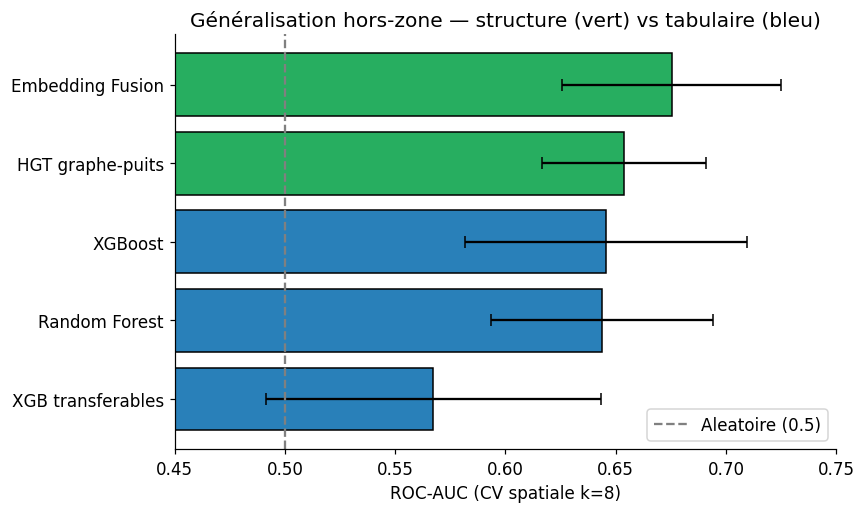

In [29]:
if RUN_SPATIAL_CV and {"latitude", "longitude"}.issubset(df.columns):
    yall = df["target"].values
    blocks = KMeans(SPATIAL_CV_K, random_state=RANDOM_STATE, n_init=10).fit_predict(
        StandardScaler().fit_transform(df[["latitude", "longitude"]].values))
    print("Tailles des blocs spatiaux :", np.bincount(blocks))
    # colonnes tabulaires SANS la feature spatiale etiquetee (exclue hors-zone)
    rows = []
    transfer_cols = [c for c in TRANSFER_FEATURES if c in num_cols]   # plancher mecaniste
    hgt_bp = bp if (TORCH_GEOMETRIC_AVAILABLE and "bp" in dir()) else dict(
        hidden_channels=128, num_heads=4, num_layers=2, dropout=0.3, lr=3e-3, weight_decay=1e-5)
    print(f"Bras 'transferable' : {len(transfer_cols)} features mecanistes -> {transfer_cols}")

    for f in range(SPATIAL_CV_K):
        te_mask = blocks == f; tr_mask = ~te_mask
        if te_mask.sum() < 50 or len(np.unique(yall[te_mask])) < 2:
            continue
        idx_tr_all = np.where(tr_mask)[0]; idx_te = np.where(te_mask)[0]
        # ── preprocesseur + scaler refit sur le train du fold ──
        ct = ColumnTransformer([
            ("num", Pipeline([("im", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([("im", SimpleImputer(strategy="constant", fill_value="Unknown")),
                              ("en", OrdinalEncoder(handle_unknown="use_encoded_value",
                                     unknown_value=-1, encoded_missing_value=-1))]), cat_cols)])
        ct.fit(df.iloc[idx_tr_all][feature_names])
        Xall_p = ct.transform(df[feature_names])            # ordre global
        Xtr, Xte = Xall_p[idx_tr_all], Xall_p[idx_te]
        ytr, yte = yall[idx_tr_all], yall[idx_te]
        spw = (ytr == 0).sum() / max(1, (ytr == 1).sum())

        # ── modeles tabulaires ──
        for name_, mdl in [
            ("XGBoost", xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.08,
                subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                tree_method="hist", random_state=RANDOM_STATE, eval_metric="logloss")),
            ("Random Forest", RandomForestClassifier(n_estimators=400, class_weight="balanced",
                n_jobs=-1, random_state=RANDOM_STATE))]:
            mdl.fit(Xtr, ytr); p = mdl.predict_proba(Xte)[:, 1]
            rows.append(dict(model=name_, fold=f, n_test=int(te_mask.sum()),
                             prev=float(yte.mean()), AUC=roc_auc_score(yte, p),
                             AP=average_precision_score(yte, p)))

        # ── bras "features transferables seules" (plancher honnete d'extrapolation) ──
        if SPATIAL_CV_TRANSFER and transfer_cols:
            ti = [num_cols.index(c) for c in transfer_cols]
            mt = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                subsample=0.8, colsample_bytree=0.9, scale_pos_weight=spw,
                tree_method="hist", random_state=RANDOM_STATE, eval_metric="logloss")
            mt.fit(Xtr[:, ti], ytr); pt = mt.predict_proba(Xte[:, ti])[:, 1]
            rows.append(dict(model="XGB transferables", fold=f, n_test=int(te_mask.sum()),
                             prev=float(yte.mean()), AUC=roc_auc_score(yte, pt),
                             AP=average_precision_score(yte, pt)))

        # ── HGT (+ fusion) reconstruit et reentraine sur ce fold ──
        if SPATIAL_CV_HGT and TORCH_GEOMETRIC_AVAILABLE:
            sc_f = StandardScaler().fit(Xtr)
            Xall_sc_f = sc_f.transform(Xall_p)
            # val interne PAR PUITS (15% des puits du train du fold)
            tr_wells_f = np.unique(winv[idx_tr_all])
            rng = np.random.RandomState(RANDOM_STATE); rng.shuffle(tr_wells_f)
            n_val_w = max(1, int(SPATIAL_CV_INNER_VAL * len(tr_wells_f)))
            val_wells = set(tr_wells_f[:n_val_w].tolist())
            is_val = np.array([w in val_wells for w in winv])
            idx_va_f = idx_tr_all[is_val[idx_tr_all]]
            idx_tr_f = idx_tr_all[~is_val[idx_tr_all]]
            gdata = assemble_well_graph(Xall_sc_f, yall, idx_tr_f, idx_va_f, idx_te)
            meta_f = gdata.metadata()
            mdl = HGT_Classifier(meta_f, hidden_channels=hgt_bp["hidden_channels"],
                num_heads=hgt_bp["num_heads"], num_layers=hgt_bp["num_layers"],
                dropout=hgt_bp["dropout"]).to(device)
            with torch.no_grad():
                _xd, _ed = graph_tensors(gdata); _ = mdl(_xd, _ed)
            mdl, _ = train_hgt(mdl, gdata, epochs=SPATIAL_CV_HGT_EPOCHS,
                lr=hgt_bp["lr"], weight_decay=hgt_bp["weight_decay"],
                es_patience=SPATIAL_CV_HGT_PATIENCE, verbose=False)
            mdl.eval()
            with torch.no_grad():
                xd, ed = graph_tensors(gdata)
                proba_f = F.softmax(mdl(xd, ed), dim=1)[:, 1].cpu().numpy()
                emb_f = mdl(xd, ed, return_embeddings=True).cpu().numpy()
            p_hgt = proba_f[idx_te]
            rows.append(dict(model="HGT graphe-puits", fold=f, n_test=int(te_mask.sum()),
                             prev=float(yte.mean()), AUC=roc_auc_score(yte, p_hgt),
                             AP=average_precision_score(yte, p_hgt)))
            if SPATIAL_CV_FUSION:
                pca_f = PCA(n_components=0.95, random_state=RANDOM_STATE).fit(emb_f[idx_tr_all])
                ef = pca_f.transform(emb_f)
                Xtr_fus = np.concatenate([Xtr, ef[idx_tr_all]], axis=1)
                Xte_fus = np.concatenate([Xte, ef[idx_te]], axis=1)
                cf = xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.08,
                    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                    tree_method="hist", random_state=RANDOM_STATE, eval_metric="logloss")
                cf.fit(Xtr_fus, ytr); pf = cf.predict_proba(Xte_fus)[:, 1]
                rows.append(dict(model="Embedding Fusion", fold=f, n_test=int(te_mask.sum()),
                                 prev=float(yte.mean()), AUC=roc_auc_score(yte, pf),
                                 AP=average_precision_score(yte, pf)))
        _last = {r["model"]: r["AUC"] for r in rows if r["fold"] == f}
        print(f"  fold {f} (n_test={int(te_mask.sum()):5d}, prev={yte.mean():.2f}) : "
              + " | ".join(f"{k[:12]}={v:.3f}" for k, v in _last.items()))

    cv_sp = pd.DataFrame(rows)
    cv_sp.to_csv(RES_DIR / "cv_spatiale.csv", index=False)
    summary_sp = cv_sp.groupby("model").agg(AUC_moy=("AUC", "mean"), AUC_std=("AUC", "std"),
                                            AP_moy=("AP", "mean")).round(4).sort_values("AUC_moy", ascending=False)
    print("\n===== CV SPATIALE (AUC honnete hors-zone) =====")
    print(summary_sp.to_string())
    print("\nRappel : en split par puits (interpolation), tous ~0.90-0.91.")

    # figure barres AUC spatiale par modele
    fig, ax = plt.subplots(figsize=(8, 4.8))
    g = cv_sp.groupby("model").AUC.agg(["mean", "std"]).sort_values("mean")
    cols = ["#27ae60" if "HGT" in m or "Fusion" in m else "#2980b9" for m in g.index]
    ax.barh(range(len(g)), g["mean"], xerr=g["std"], color=cols, edgecolor="black", capsize=4)
    ax.axvline(0.5, ls="--", c="grey", label="Aleatoire (0.5)")
    ax.set_yticks(range(len(g))); ax.set_yticklabels(g.index)
    ax.set_xlim(0.45, max(0.75, g["mean"].max()+0.06)); ax.set_xlabel("ROC-AUC (CV spatiale k=8)")
    ax.set_title("Généralisation hors-zone — structure (vert) vs tabulaire (bleu)")
    ax.legend(); plt.tight_layout(); savefig(fig, "fig15_cv_spatiale_hgt.png"); plt.show()
else:
    print("CV spatiale desactivee (RUN_SPATIAL_CV=False).")

In [30]:
cv_summary = None
if RUN_SPATIAL_CV and "cv_sp" in dir() and len(cv_sp):
    cv_summary = {m: {"AUC_moy": round(float(g["AUC"].mean()), 4),
                      "AUC_std": round(float(g["AUC"].std()), 4),
                      "AP_moy": round(float(g["AP"].mean()), 4)}
                  for m, g in cv_sp.groupby("model")}

summary = {
    "notebook": "13 — HGT graphe-puits evalue en CV spatiale",
    "target": "EPA 2024 NPDWR (MCL individuels + Indice de Risque melange)",
    "dataset": {"n_total": int(len(df)), "n_wells": int(n_wells), "n_features": len(proc_cols)},
    "split": {"mode": "group_by_well" if GROUP_SPLIT_BY_WELL else "random_stratified",
              "train": int(len(idx_train)), "val": int(len(idx_val)), "test": int(len(idx_test))},
    "config": {"OPTUNA_MODE": OPTUNA_MODE, "EPOCHS_HGT": EPOCHS_HGT,
               "WELL_KNN_K": WELL_KNN_K, "WELL_BANDS_KM": list(WELL_BANDS_KM),
               "SOURCE_BANDS_KM": list(SOURCE_BANDS_KM),
               "ADD_SPATIAL_LABEL_FEATURES": ADD_SPATIAL_LABEL_FEATURES,
               "SPATIAL_CV_HGT": SPATIAL_CV_HGT, "SPATIAL_CV_K": SPATIAL_CV_K,
               "hgt_best_params": bp if TORCH_GEOMETRIC_AVAILABLE else None},
    "results_interpolation": {m: {k: round(float(v), 4) for k, v in RESULTS[m]["metrics"].items() if k != "name"}
                for m in RESULTS},
    "results_cv_spatiale": cv_summary,
    "best_model_auc": best,
    "nb11_reference": {"HGT": 0.8425, "RF": 0.8910, "XGB": 0.9059,
                       "Fusion": 0.8808, "Stacking": 0.9061},
}
with open(RES_DIR / "synthese_resultats.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

with open(MODELS_DIR / "random_forest.pkl", "wb") as f: pickle.dump(rf, f)
with open(MODELS_DIR / "xgboost.pkl", "wb") as f: pickle.dump(xgb_model, f)
with open(MODELS_DIR / "preprocessor.pkl", "wb") as f: pickle.dump(preprocessor, f)
with open(MODELS_DIR / "scaler.pkl", "wb") as f: pickle.dump(scaler, f)
if TORCH_GEOMETRIC_AVAILABLE:
    torch.save({"state_dict": hgt_model.state_dict(), "metadata": data.metadata(),
                "params": bp}, MODELS_DIR / "hgt_graphe_puits.pt")
    with open(MODELS_DIR / "xgb_fusion.pkl", "wb") as f: pickle.dump(xgb_fusion, f)
    with open(MODELS_DIR / "meta_lr.pkl", "wb") as f: pickle.dump(meta_lr, f)
print("Artefacts sauvegardes dans", OUT_DIR.resolve())
print("Interpolation :", json.dumps(summary["results_interpolation"], indent=2, ensure_ascii=False))
print("CV spatiale   :", json.dumps(summary["results_cv_spatiale"], indent=2, ensure_ascii=False))

zip_path = Path(f"PFAS_HGT_cv_spatiale_outputs_loc_{time.strftime('%Y%m%d_%H%M')}.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in (FIG_DIR, RES_DIR):
        for p in folder.rglob("*"):
            if p.is_file():
                zf.write(p, p.relative_to(OUT_DIR))
print(f"Archive creee : {zip_path}  ({zip_path.stat().st_size/1e6:.1f} Mo)")
if IN_COLAB:
    from google.colab import files
    files.download(str(zip_path))

Artefacts sauvegardes dans /content/outputs_notebook_cv_spatiale
Interpolation : {
  "Random Forest": {
    "roc_auc": 0.8985,
    "avg_precision": 0.8813,
    "accuracy": 0.8145,
    "balanced_accuracy": 0.8046,
    "precision": 0.8302,
    "recall": 0.7248,
    "f1": 0.7739
  },
  "XGBoost": {
    "roc_auc": 0.9116,
    "avg_precision": 0.8961,
    "accuracy": 0.8273,
    "balanced_accuracy": 0.8188,
    "precision": 0.8389,
    "recall": 0.7499,
    "f1": 0.7919
  },
  "HGT graphe-puits": {
    "roc_auc": 0.9006,
    "avg_precision": 0.8845,
    "accuracy": 0.817,
    "balanced_accuracy": 0.8136,
    "precision": 0.7941,
    "recall": 0.7862,
    "f1": 0.7901
  },
  "Embedding Fusion": {
    "roc_auc": 0.9122,
    "avg_precision": 0.8973,
    "accuracy": 0.8266,
    "balanced_accuracy": 0.8216,
    "precision": 0.8151,
    "recall": 0.7815,
    "f1": 0.7979
  },
  "Stacking": {
    "roc_auc": 0.9137,
    "avg_precision": 0.8984,
    "accuracy": 0.8329,
    "balanced_accuracy": 0.824

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>